In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010030rest 20160324 1054..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020025rest 20150713 1519..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010013rest 20150703 1333..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020016rest 20150701 1040..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020015_rest 20150630 1527.csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010022restnew 20150724 14.csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020027rest 20150713 1049..csv
/kaggle/input/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010008_rest 20150619 1653.csv
/kaggle/input/preprocessed-raw-m

# **SETUP SAVE AND SPLITS**

In [2]:
# ================================================================================================
# MODMA DOT PROBE TASK PIPELINE — MEMORY-EFFICIENT CSV VERSION
# ================================================================================================
#
# FIXES APPLIED:
# 1. Proper handling of 0202 (Fear-Neutral condition) files — explicitly excluded
# 2. Memory-efficient processing — incremental windowing, chunked operations
# 3. Downsampling BEFORE windowing to reduce memory footprint
# 4. Garbage collection between subjects
#
# ================================================================================================

import os
import re
import gc
import json
import warnings
from collections import defaultdict
from typing import Tuple, List, Optional
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.signal import decimate

# ================================================================================================
# CONFIGURATION
# ================================================================================================

CSV_DATA_DIR = "/kaggle/input/preprocessed-raw-mat-csv/raw-csv-actual/raw-csv-actual/csv_from_raw1"
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ================================================================================================
# HYPERPARAMETERS
# ================================================================================================

# Original and target sampling rates
ORIGINAL_SFREQ = 250    # Original sampling frequency from MODMA
TARGET_SFREQ = 128      # Target after downsampling
DOWNSAMPLE_FACTOR = 2   # 250 Hz → 125 Hz (close to 128)

# Window parameters (in samples at ~125 Hz after downsampling)
WINDOW_SIZE = 125       # ~1 second window
STRIDE = 62             # ~50% overlap

# Train/test split
TEST_SIZE = 0.2
SEED = 42
VALIDATE_NO_LEAKAGE = True

# Memory management
BATCH_SAVE_SIZE = 10000  # Save to disk every N windows to free memory

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ================================================================================================
# GPU CONFIGURATION
# ================================================================================================

gpus = tf.config.experimental.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
        print(f"✓ GPU memory growth enabled: {g}")
    except Exception as e:
        print(f"✗ GPU config failed: {e}")

if not gpus:
    print("ℹ No GPU detected — running on CPU")

# ================================================================================================
# HELPER FUNCTIONS
# ================================================================================================

def extract_subject_id_and_label(filename: str) -> Tuple[Optional[str], Optional[int], Optional[str]]:
    """
    Extract subject ID and diagnostic label from MODMA ERP filename.
    
    MODMA ERP Naming Convention:
    ----------------------------
    - "0201XXXX..." → MDD patient (label = 1)
    - "0202XXXX..." → Fear-Neutral condition (EXCLUDED from classification)
    - "0203XXXX..." → Healthy Control (label = 0)
    
    Returns:
        (subject_id, label, skip_reason) tuple
        - If valid: (subject_id, label, None)
        - If should skip: (None, None, reason_string)
    """
    basename = os.path.splitext(filename)[0]
    
    # Pattern: 0201XXXX, 0202XXXX, or 0203XXXX at start (with optional underscore)
    match = re.match(r'^(020[123])_?(\d{4})', basename)
    if match:
        group_code = match.group(1)
        subject_num = match.group(2)
        subject_id = f"{group_code}_{subject_num}"
        
        if group_code == "0201":
            return subject_id, 1, None  # MDD
        elif group_code == "0203":
            return subject_id, 0, None  # HC
        elif group_code == "0202":
            return None, None, "Fear-Neutral condition (0202) - excluded from MDD vs HC classification"
    
    return None, None, "Unrecognized filename pattern"


def detect_eeg_columns(columns: List[str]) -> List[str]:
    """Detect and sort EEG electrode columns (E1-E128)."""
    eeg_cols = []
    for col in columns:
        match = re.match(r'^E(\d+)$', col, re.IGNORECASE)
        if match:
            num = int(match.group(1))
            if 1 <= num <= 128:
                eeg_cols.append((num, col))
    eeg_cols.sort(key=lambda x: x[0])
    return [col for _, col in eeg_cols]


def verify_no_subject_leakage(train_subjects: set, test_subjects: set) -> bool:
    """Verify zero overlap between training and test subjects."""
    overlap = train_subjects & test_subjects
    if overlap:
        raise AssertionError(f"DATA LEAKAGE! {len(overlap)} subject(s) in both sets: {overlap}")
    return True


def downsample_data(data: np.ndarray, factor: int) -> np.ndarray:
    """Downsample along time axis (axis=0) using scipy decimate."""
    if factor <= 1:
        return data
    # Decimate each channel separately
    n_samples, n_channels = data.shape
    new_length = n_samples // factor
    downsampled = np.zeros((new_length, n_channels), dtype=np.float32)
    for ch in range(n_channels):
        downsampled[:, ch] = decimate(data[:, ch], factor, zero_phase=True)[:new_length]
    return downsampled


def create_windows(data: np.ndarray, window_size: int, stride: int) -> np.ndarray:
    """
    Create windows from continuous data.
    
    Parameters:
        data: shape (timepoints, channels)
        window_size: samples per window
        stride: step between windows
    
    Returns:
        windows: shape (n_windows, channels, window_size)
    """
    n_samples, n_channels = data.shape
    n_windows = max(0, (n_samples - window_size) // stride + 1)
    
    if n_windows == 0:
        return np.array([]).reshape(0, n_channels, window_size)
    
    # Use stride tricks for memory efficiency
    from numpy.lib.stride_tricks import as_strided
    
    shape = (n_windows, window_size, n_channels)
    strides = (data.strides[0] * stride, data.strides[0], data.strides[1])
    windows = as_strided(data, shape=shape, strides=strides)
    
    # Copy and transpose to (n_windows, channels, window_size)
    return np.array(windows).transpose(0, 2, 1).astype(np.float32)


# ================================================================================================
# MEMORY-EFFICIENT DATA LOADING
# ================================================================================================

def load_and_process_csv_files(data_dir: str) -> Tuple[str, dict]:
    """
    Load CSV files incrementally and save processed windows to disk.
    
    Returns:
        temp_npz_path: Path to temporary NPZ with all windows
        metadata: Dictionary with dataset statistics
    """
    print("=" * 80)
    print("Loading CSV files (Memory-Efficient Mode)")
    print("=" * 80)
    
    csv_files = sorted([f for f in os.listdir(data_dir) if f.lower().endswith('.csv')])
    
    if not csv_files:
        raise RuntimeError(f"No CSV files found in {data_dir}")
    
    print(f"Found {len(csv_files)} CSV files\n")
    
    # Track what we're processing
    subject_info = {}  # subject_id -> {'label': int, 'n_windows': int}
    channel_names = None
    
    # Temporary storage for incremental saves
    temp_windows_path = os.path.join(OUTPUT_DIR, '_temp_windows.npz')
    all_windows_list = []
    all_labels_list = []
    all_subjects_list = []
    total_windows = 0
    
    # Statistics
    stats = {
        'files_mdd': 0, 'files_hc': 0, 'files_fear_neutral': 0, 
        'files_unrecognized': 0, 'files_error': 0
    }
    
    print("Processing files:")
    print("-" * 60)
    
    for i, filename in enumerate(csv_files):
        filepath = os.path.join(data_dir, filename)
        subject_id, label, skip_reason = extract_subject_id_and_label(filename)
        
        # Handle skipped files
        if skip_reason:
            if "0202" in skip_reason:
                stats['files_fear_neutral'] += 1
                if i < 5 or stats['files_fear_neutral'] == 1:  # Print first few
                    print(f"  ⊘ {filename[:40]}... → SKIP (Fear-Neutral 0202)")
            else:
                stats['files_unrecognized'] += 1
                print(f"  ⚠ {filename[:40]}... → SKIP ({skip_reason})")
            continue
        
        try:
            # Read CSV
            df = pd.read_csv(filepath)
            
            # Detect EEG columns (first file only)
            if channel_names is None:
                channel_names = detect_eeg_columns(df.columns.tolist())
                if not channel_names:
                    raise ValueError("No EEG columns found")
                print(f"\n  Detected {len(channel_names)} EEG channels\n")
            
            # Extract and downsample
            data = df[channel_names].values.astype(np.float32)
            del df  # Free memory
            gc.collect()
            
            # Downsample to reduce memory
            data = downsample_data(data, DOWNSAMPLE_FACTOR)
            
            # Create windows
            windows = create_windows(data, WINDOW_SIZE, STRIDE)
            del data
            gc.collect()
            
            n_windows = len(windows)
            if n_windows == 0:
                print(f"  ⚠ {filename[:40]}... → No windows (too short)")
                continue
            
            # Track subject info
            if subject_id not in subject_info:
                subject_info[subject_id] = {'label': label, 'n_windows': 0}
            subject_info[subject_id]['n_windows'] += n_windows
            
            # Accumulate
            all_windows_list.append(windows)
            all_labels_list.extend([label] * n_windows)
            all_subjects_list.extend([subject_id] * n_windows)
            total_windows += n_windows
            
            # Update stats
            if label == 1:
                stats['files_mdd'] += 1
            else:
                stats['files_hc'] += 1
            
            diagnosis = "MDD" if label == 1 else "HC"
            print(f"  ✓ {subject_id} ({diagnosis}): {n_windows:,} windows")
            
            # Periodic garbage collection
            if (i + 1) % 10 == 0:
                gc.collect()
                
        except Exception as e:
            stats['files_error'] += 1
            print(f"  ✗ {filename[:40]}... → ERROR: {e}")
            continue
    
    print("-" * 60)
    print(f"\nFile Processing Summary:")
    print(f"  • MDD files processed: {stats['files_mdd']}")
    print(f"  • HC files processed: {stats['files_hc']}")
    print(f"  • Fear-Neutral (0202) excluded: {stats['files_fear_neutral']}")
    print(f"  • Unrecognized patterns: {stats['files_unrecognized']}")
    print(f"  • Errors: {stats['files_error']}")
    
    if not all_windows_list:
        raise RuntimeError("No valid windows created!")
    
    # Concatenate all windows
    print(f"\nConcatenating {total_windows:,} windows...")
    X = np.concatenate(all_windows_list, axis=0)
    y = np.array(all_labels_list, dtype=np.int32)
    subject_ids = np.array(all_subjects_list)
    
    # Clear lists to free memory
    del all_windows_list, all_labels_list, all_subjects_list
    gc.collect()
    
    print(f"✓ Final shape: {X.shape} (windows × channels × timepoints)")
    
    # Save to temporary file
    np.savez_compressed(temp_windows_path, X=X, y=y, subject_ids=subject_ids)
    print(f"✓ Saved to temporary file: {temp_windows_path}")
    
    # Build metadata
    metadata = {
        'n_subjects': len(subject_info),
        'n_mdd': sum(1 for s in subject_info.values() if s['label'] == 1),
        'n_hc': sum(1 for s in subject_info.values() if s['label'] == 0),
        'total_windows': total_windows,
        'channel_names': channel_names,
        'subject_info': subject_info,
        'stats': stats
    }
    
    return temp_windows_path, metadata


# ================================================================================================
# MAIN PIPELINE
# ================================================================================================

print("\n" + "=" * 80)
print("MODMA DOT PROBE TASK PIPELINE — MEMORY-EFFICIENT VERSION")
print("MDD vs HC Classification (0202 Fear-Neutral Excluded)")
print("=" * 80 + "\n")

# ================================================================================================
# STEP 1: LOAD AND PROCESS DATA
# ================================================================================================

print("STEP 1: Loading and processing CSV files")
print("-" * 40)

temp_path, metadata = load_and_process_csv_files(CSV_DATA_DIR)

# Load back from temp file
print("\nLoading processed data from temp file...")
temp_data = np.load(temp_path, allow_pickle=True)
X = temp_data['X']
y = temp_data['y']
subject_ids = temp_data['subject_ids']
channel_names = metadata['channel_names']

# ================================================================================================
# STEP 2: DATA SUMMARY
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 2: Data Summary")
print("=" * 80)

unique_subjects = np.unique(subject_ids)
n_subjects = len(unique_subjects)
n_mdd = metadata['n_mdd']
n_hc = metadata['n_hc']
n_channels = X.shape[1]
n_times = X.shape[2]

print(f"\nDataset Statistics:")
print(f"  • Total subjects: {n_subjects} ({n_mdd} MDD, {n_hc} HC)")
print(f"  • Total windows: {X.shape[0]:,}")
print(f"  • Channels: {n_channels}")
print(f"  • Timepoints per window: {n_times}")
print(f"  • MDD windows: {np.sum(y == 1):,}")
print(f"  • HC windows: {np.sum(y == 0):,}")

# ================================================================================================
# STEP 3: HANDLE MISSING VALUES
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 3: Handling missing values")
print("=" * 80)

nan_count = np.isnan(X).sum()
if nan_count > 0:
    print(f"⚠ Found {nan_count:,} NaN values — imputing with channel means")
    for ch in range(X.shape[1]):
        ch_data = X[:, ch, :]
        ch_mean = np.nanmean(ch_data)
        X[:, ch, :] = np.where(np.isnan(ch_data), ch_mean, ch_data)
    print("✓ Imputation complete")
else:
    print("✓ No missing values detected")

# ================================================================================================
# STEP 4: SUBJECT-WISE TRAIN-TEST SPLIT
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 4: Subject-wise train-test split (CRITICAL)")
print("=" * 80)

print(f"\nSplitting {n_subjects} subjects with {TEST_SIZE:.0%} held out for testing")
print("⚠ All windows from each subject stay in same partition\n")

# Get labels per subject for stratification
subject_labels = []
for subj in unique_subjects:
    subj_mask = subject_ids == subj
    subject_labels.append(y[subj_mask][0])
subject_labels = np.array(subject_labels)

# Split at SUBJECT level
subjects_train, subjects_test = train_test_split(
    unique_subjects,
    test_size=TEST_SIZE,
    stratify=subject_labels,
    random_state=SEED
)

# Create masks
train_mask = np.isin(subject_ids, subjects_train)
test_mask = np.isin(subject_ids, subjects_test)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
subj_train, subj_test = subject_ids[train_mask], subject_ids[test_mask]

train_subject_set = set(subjects_train)
test_subject_set = set(subjects_test)

print(f"Training set:")
print(f"  • Subjects: {len(train_subject_set)}")
print(f"  • Windows: {X_train.shape[0]:,}")
print(f"  • MDD: {np.sum(y_train == 1):,}, HC: {np.sum(y_train == 0):,}")

print(f"\nTest set:")
print(f"  • Subjects: {len(test_subject_set)}")
print(f"  • Windows: {X_test.shape[0]:,}")
print(f"  • MDD: {np.sum(y_test == 1):,}, HC: {np.sum(y_test == 0):,}")

# Free original arrays
del X, y, subject_ids
gc.collect()

# ================================================================================================
# STEP 5: VALIDATE NO LEAKAGE
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 5: Validating no subject overlap")
print("=" * 80)

if VALIDATE_NO_LEAKAGE:
    verify_no_subject_leakage(train_subject_set, test_subject_set)
    print("✓ VALIDATION PASSED: Zero subject overlap")

# ================================================================================================
# STEP 6: NORMALIZE (MEMORY-EFFICIENT)
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 6: Standardization (fit on TRAINING only)")
print("=" * 80)

n_train = X_train.shape[0]
n_test = X_test.shape[0]

# Compute statistics on training data only
print("Computing scaler statistics from training data...")

# Reshape: (windows, channels, times) -> (windows*times, channels)
X_train_flat = X_train.transpose(0, 2, 1).reshape(-1, n_channels)

scaler = StandardScaler()
scaler.fit(X_train_flat)

# Transform training data
X_train_scaled = scaler.transform(X_train_flat).astype(np.float32)
X_train_scaled = X_train_scaled.reshape(n_train, n_times, n_channels).transpose(0, 2, 1)

del X_train_flat, X_train
gc.collect()

# Transform test data
X_test_flat = X_test.transpose(0, 2, 1).reshape(-1, n_channels)
X_test_scaled = scaler.transform(X_test_flat).astype(np.float32)
X_test_scaled = X_test_scaled.reshape(n_test, n_times, n_channels).transpose(0, 2, 1)

del X_test_flat, X_test
gc.collect()

print(f"✓ Train: mean={X_train_scaled.mean():.6f}, std={X_train_scaled.std():.6f}")
print(f"✓ Test: mean={X_test_scaled.mean():.6f}, std={X_test_scaled.std():.6f}")

# ================================================================================================
# STEP 7: RESHAPE FOR DEEP LEARNING
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 7: Preparing data for deep learning")
print("=" * 80)

# EEGNet format: (samples, 1, channels, timepoints)
X_train_dl = X_train_scaled[:, np.newaxis, :, :]
X_test_dl = X_test_scaled[:, np.newaxis, :, :]

print(f"Training shape (EEGNet): {X_train_dl.shape}")
print(f"Test shape (EEGNet): {X_test_dl.shape}")

# Flattened for traditional ML
X_train_flat = X_train_scaled.reshape(n_train, -1)
X_test_flat = X_test_scaled.reshape(n_test, -1)

print(f"Flattened shape (ML): {X_train_flat.shape}")

# ================================================================================================
# STEP 8: SAVE PROCESSED DATA
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 8: Saving processed data")
print("=" * 80)

npz_path = os.path.join(OUTPUT_DIR, 'dotprobe_data_split.npz')
np.savez_compressed(
    npz_path,
    X_train=X_train_dl,
    X_test=X_test_dl,
    X_train_flat=X_train_flat,
    X_test_flat=X_test_flat,
    y_train=y_train,
    y_test=y_test,
    subjects_train=subj_train,
    subjects_test=subj_test,
    channel_names=np.array(channel_names),
    scaler_mean=scaler.mean_,
    scaler_scale=scaler.scale_
)
print(f"✓ Saved: {npz_path}")

# Save metadata
full_metadata = {
    "dataset": "MODMA_DotProbe_TaskState",
    "task": "MDD_vs_HC_classification",
    "excluded": "0202 Fear-Neutral condition files",
    "preprocessing": {
        "original_sfreq": ORIGINAL_SFREQ,
        "downsample_factor": DOWNSAMPLE_FACTOR,
        "effective_sfreq": ORIGINAL_SFREQ // DOWNSAMPLE_FACTOR,
        "window_size": WINDOW_SIZE,
        "stride": STRIDE,
        "window_duration_ms": WINDOW_SIZE / (ORIGINAL_SFREQ // DOWNSAMPLE_FACTOR) * 1000
    },
    "splitting": {
        "method": "subject_wise_stratified",
        "test_size": TEST_SIZE,
        "seed": SEED
    },
    "subjects": {
        "total": n_subjects,
        "mdd": n_mdd,
        "hc": n_hc,
        "train": sorted(list(train_subject_set)),
        "test": sorted(list(test_subject_set))
    },
    "samples": {
        "train": int(n_train),
        "test": int(n_test),
        "train_mdd": int(np.sum(y_train == 1)),
        "train_hc": int(np.sum(y_train == 0)),
        "test_mdd": int(np.sum(y_test == 1)),
        "test_hc": int(np.sum(y_test == 0))
    },
    "shapes": {
        "X_train_dl": list(X_train_dl.shape),
        "X_test_dl": list(X_test_dl.shape)
    }
}

metadata_path = os.path.join(OUTPUT_DIR, 'dotprobe_preprocessing_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(full_metadata, f, indent=2)
print(f"✓ Saved: {metadata_path}")

# Clean up temp file
if os.path.exists(temp_path):
    os.remove(temp_path)
    print(f"✓ Removed temp file")

# ================================================================================================
# SUMMARY
# ================================================================================================

print("\n" + "=" * 80)
print("✅ PIPELINE COMPLETE")
print("=" * 80)

print(f"""
DATASET:
  • Subjects: {n_subjects} ({n_mdd} MDD, {n_hc} HC)
  • 0202 Fear-Neutral files: EXCLUDED
  • Windows: {n_train + n_test:,} total

TRAIN/TEST SPLIT (Subject-Wise):
  • Train: {len(train_subject_set)} subjects, {n_train:,} windows
  • Test: {len(test_subject_set)} subjects, {n_test:,} windows
  • Leakage: NONE ✓

DATA SHAPES:
  • EEGNet: {X_train_dl.shape}
  • ML: {X_train_flat.shape}

FILES SAVED:
  • {npz_path}
  • {metadata_path}

FOR YOUR PAPER:
  1. 0202 Fear-Neutral condition excluded (not diagnostic group)
  2. Downsampling: {ORIGINAL_SFREQ} Hz → {ORIGINAL_SFREQ // DOWNSAMPLE_FACTOR} Hz
  3. Window: {WINDOW_SIZE} samples (~{WINDOW_SIZE / (ORIGINAL_SFREQ // DOWNSAMPLE_FACTOR) * 1000:.0f} ms)
  4. Subject-wise stratified split prevents data leakage
  5. Normalization fit on training data only
""")

print("Ready for model training!")

2026-01-25 11:47:28.455605: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769341648.637214      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769341648.688419      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769341649.123009      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769341649.123048      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769341649.123050      55 computation_placer.cc:177] computation placer alr

✓ GPU memory growth enabled: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

MODMA DOT PROBE TASK PIPELINE — MEMORY-EFFICIENT VERSION
MDD vs HC Classification (0202 Fear-Neutral Excluded)

STEP 1: Loading and processing CSV files
----------------------------------------
Loading CSV files (Memory-Efficient Mode)
Found 50 CSV files

Processing files:
------------------------------------------------------------

  Detected 128 EEG channels

  ✓ 0201_0002 (MDD): 1,590 windows
  ✓ 0201_0004 (MDD): 1,571 windows
  ✓ 0201_0005 (MDD): 1,877 windows
  ✓ 0201_0006 (MDD): 1,571 windows
  ✓ 0201_0008 (MDD): 1,620 windows
  ✓ 0201_0010 (MDD): 1,741 windows
  ✓ 0201_0011 (MDD): 1,726 windows
  ✓ 0201_0012 (MDD): 1,641 windows
  ✓ 0201_0013 (MDD): 1,698 windows
  ✓ 0201_0015 (MDD): 1,627 windows
  ✓ 0201_0016 (MDD): 1,625 windows
  ✓ 0201_0018 (MDD): 1,622 windows
  ✓ 0201_0019 (MDD): 1,579 windows
  ✓ 0201_0021 (MDD): 1,652 windows
  ✓ 0201_0022 (MDD): 1,621 windows
  ✓ 0201_0023 (

# **STATISTICAL-ANALYSIS**

In [2]:
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import pearsonr

# Load the preprocessed split data
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, 'dotprobe_data_split.npz')

data = np.load(DATA_PATH, allow_pickle=True)
X_train = data['X_train']  # (samples, 1, channels, timepoints) or similar
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# Concatenate to get full dataset for analysis (or use only test set if preferred)
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

# Squeeze if needed (adjust based on your exact shape; assuming (samples, 1, channels, timepoints))
X = np.squeeze(X, axis=1)  # Now (samples, channels, timepoints)

# Function to compute connectivity matrix (absolute Pearson correlation between channels)
def compute_connectivity(eeg_sample):
    # eeg_sample: (channels, timepoints)
    n_channels = eeg_sample.shape[0]
    conn_matrix = np.zeros((n_channels, n_channels))
    for i in range(n_channels):
        for j in range(i + 1, n_channels):
            corr, _ = pearsonr(eeg_sample[i], eeg_sample[j])
            conn = abs(corr)
            conn_matrix[i, j] = conn
            conn_matrix[j, i] = conn
    return conn_matrix

# Function to compute graph metrics for a group of samples
def compute_group_metrics(X_group):
    betweenness_list = []
    clustering_list = []
    
    for sample in X_group:  # sample: (channels, timepoints)
        conn_matrix = compute_connectivity(sample)
        
        # Threshold to create sparse graph (e.g., keep connections > 80th percentile)
        threshold = np.percentile(conn_matrix[conn_matrix > 0], 80) if np.any(conn_matrix > 0) else 0
        adj_matrix = (conn_matrix > threshold).astype(float)
        
        # Build graph
        G = nx.from_numpy_array(adj_matrix)
        
        # Compute metrics
        betweenness = nx.betweenness_centrality(G)
        clustering = nx.clustering(G)
        
        mean_betweenness = np.mean(list(betweenness.values())) if betweenness else 0
        mean_clustering = np.mean(list(clustering.values())) if clustering else 0
        
        betweenness_list.append(mean_betweenness)
        clustering_list.append(mean_clustering)
    
    return np.array(betweenness_list), np.array(clustering_list)

# Separate groups
group_0_mask = (y == 0)  # HC (label 0)
group_1_mask = (y == 1)  # MDD (label 1)

X_group_0 = X[group_0_mask]
X_group_1 = X[group_1_mask]

# Compute metrics
print("Computing metrics for Group 0 (HC)...")
betweenness_0, clustering_0 = compute_group_metrics(X_group_0)

print("Computing metrics for Group 1 (MDD)...")
betweenness_1, clustering_1 = compute_group_metrics(X_group_1)

# Plot 1: Boxplot for mean_betweenness vs label
data_betweenness = {
    'mean_betweenness': np.concatenate([betweenness_0, betweenness_1]),
    'label': np.concatenate([np.zeros(len(betweenness_0)), np.ones(len(betweenness_1))])
}
df_betweenness = pd.DataFrame(data_betweenness)

plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='mean_betweenness', data=df_betweenness, palette='Blues')
plt.title('Mean Betweenness by Label')
plt.xlabel('label')
plt.ylabel('mean_betweenness')
plt.savefig('mean_betweenness_boxplot.png')
plt.show()
plt.close()

# Plot 2: Boxplot for mean_clustering vs label
data_clustering = {
    'mean_clustering': np.concatenate([clustering_0, clustering_1]),
    'label': np.concatenate([np.zeros(len(clustering_0)), np.ones(len(clustering_1))])
}
df_clustering = pd.DataFrame(data_clustering)

plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='mean_clustering', data=df_clustering, palette='Blues')
plt.title('Mean Clustering by Label')
plt.xlabel('label')
plt.ylabel('mean_clustering')
plt.savefig('mean_clustering_boxplot.png')
plt.show()
plt.close()

# Plot 3: Histogram/KDE for mean_betweenness in group 0
plt.figure(figsize=(8, 4))
sns.histplot(betweenness_0, kde=True, bins=20, color='blue', label='group 0')
plt.title('Distribution of Mean Betweenness - Group 0')
plt.xlabel('mean_betweenness')
plt.ylabel('Density')
plt.legend()
plt.savefig('mean_betweenness_hist_group0.png')
plt.show()
plt.close()

# Plot 4: Histogram/KDE for mean_clustering in group 0
plt.figure(figsize=(8, 4))
sns.histplot(clustering_0, kde=True, bins=20, color='blue', label='group 0')
plt.title('Distribution of Mean Clustering - Group 0')
plt.xlabel('mean_clustering')
plt.ylabel('Density')
plt.legend()
plt.savefig('mean_clustering_hist_group0.png')
plt.show()
plt.close()

print("Plots generated and saved: mean_betweenness_boxplot.png, mean_clustering_boxplot.png, mean_betweenness_hist_group0.png, mean_clustering_hist_group0.png")

Computing metrics for Group 0 (HC)...


KeyboardInterrupt: 

Computing metrics for Group 0 (HC)...


Processing samples: 100%|██████████| 500/500 [00:12<00:00, 40.19it/s]


Computing metrics for Group 1 (MDD)...


Processing samples:   0%|          | 0/500 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/usr/local/lib/py

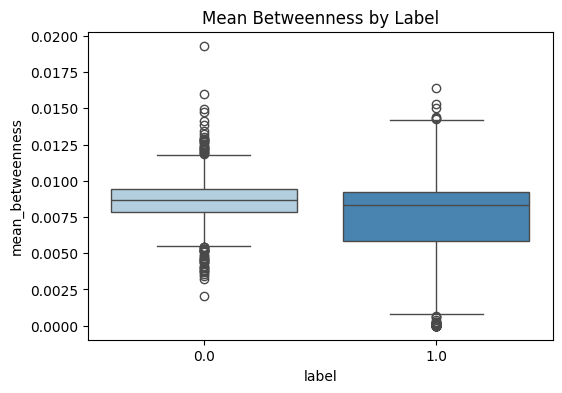

/tmp/ipykernel_55/799442612.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='mean_clustering', data=df_clustering, palette='Blues')


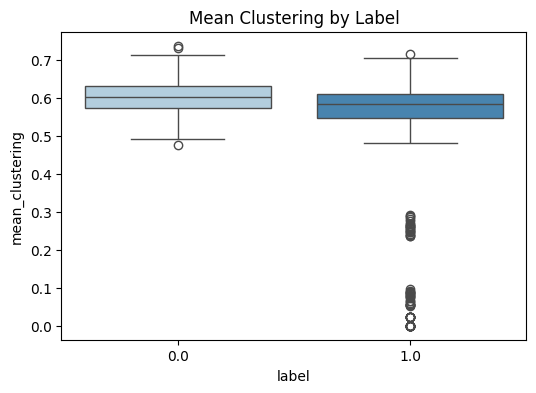

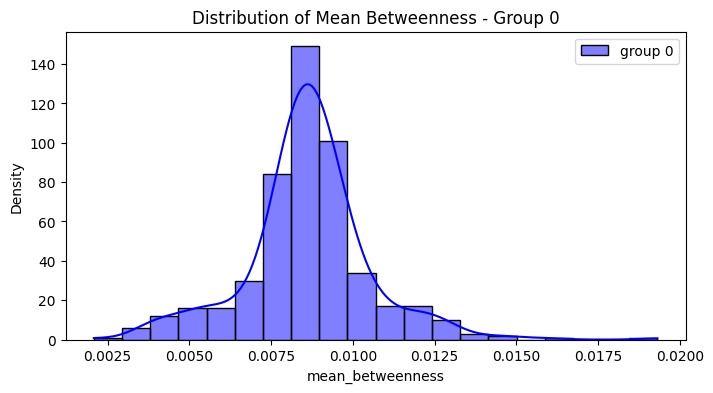

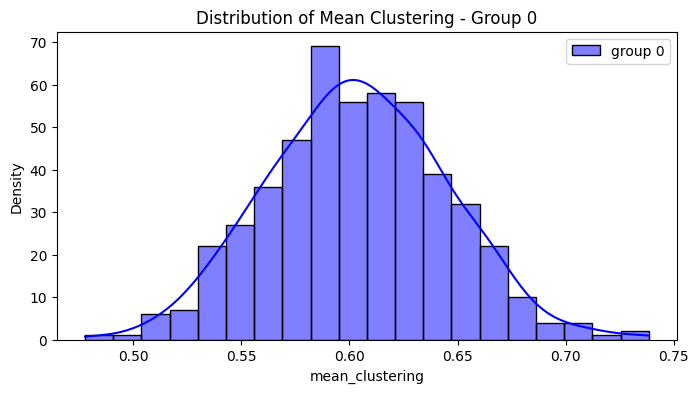

Plots generated and saved: mean_betweenness_boxplot.png, mean_clustering_boxplot.png, mean_betweenness_hist_group0.png, mean_clustering_hist_group0.png


In [3]:
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from joblib import Parallel, delayed
from tqdm import tqdm

# Load the preprocessed split data
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, 'dotprobe_data_split.npz')

data = np.load(DATA_PATH, allow_pickle=True)
X_train = data['X_train']  # (samples, 1, channels, timepoints) or similar
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']

# Concatenate to get full dataset for analysis
X = np.concatenate((X_train, X_test), axis=0)
y = np.concatenate((y_train, y_test), axis=0)

# Squeeze if needed (adjust based on your exact shape; assuming (samples, 1, channels, timepoints))
X = np.squeeze(X, axis=1)  # Now (samples, channels, timepoints)

# Function to compute connectivity matrix (vectorized for speed)
def compute_connectivity(eeg_sample):
    # eeg_sample: (channels, timepoints)
    corr_matrix = np.corrcoef(eeg_sample)
    conn_matrix = np.abs(np.triu(corr_matrix, k=1))  # Upper triangle, absolute values
    return conn_matrix + conn_matrix.T  # Symmetric

# Function to compute metrics for a single sample
def compute_metrics(sample):
    conn_matrix = compute_connectivity(sample)
    
    # Threshold to create sparse graph (e.g., keep connections > 80th percentile)
    non_zero = conn_matrix[conn_matrix > 0]
    threshold = np.percentile(non_zero, 80) if len(non_zero) > 0 else 0
    adj_matrix = (conn_matrix > threshold).astype(float)
    
    # Build graph
    G = nx.from_numpy_array(adj_matrix)
    
    # Compute metrics (approximate betweenness with k=50 for speed)
    betweenness = nx.betweenness_centrality(G, k=50)
    clustering = nx.clustering(G)
    
    mean_betweenness = np.mean(list(betweenness.values())) if betweenness else 0
    mean_clustering = np.mean(list(clustering.values())) if clustering else 0
    
    return mean_betweenness, mean_clustering

# Function to compute group metrics in parallel with subsampling
def compute_group_metrics(X_group, n_jobs=-1, subsample_size=500):
    # Subsample if large
    if len(X_group) > subsample_size:
        indices = np.random.choice(len(X_group), subsample_size, replace=False)
        X_group = X_group[indices]
    
    # Parallel computation
    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_metrics)(sample) for sample in tqdm(X_group, desc="Processing samples")
    )
    
    betweenness_list, clustering_list = zip(*results)
    return np.array(betweenness_list), np.array(clustering_list)

# Separate groups
group_0_mask = (y == 0)  # HC (label 0)
group_1_mask = (y == 1)  # MDD (label 1)

X_group_0 = X[group_0_mask]
X_group_1 = X[group_1_mask]

# Compute metrics (with parallelization and subsampling)
print("Computing metrics for Group 0 (HC)...")
betweenness_0, clustering_0 = compute_group_metrics(X_group_0)

print("Computing metrics for Group 1 (MDD)...")
betweenness_1, clustering_1 = compute_group_metrics(X_group_1)

# Plot 1: Boxplot for mean_betweenness vs label
data_betweenness = {
    'mean_betweenness': np.concatenate([betweenness_0, betweenness_1]),
    'label': np.concatenate([np.zeros(len(betweenness_0)), np.ones(len(betweenness_1))])
}
df_betweenness = pd.DataFrame(data_betweenness)

plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='mean_betweenness', data=df_betweenness, palette='Blues')
plt.title('Mean Betweenness by Label')
plt.xlabel('label')
plt.ylabel('mean_betweenness')
plt.savefig('mean_betweenness_boxplot.png')
plt.show()
plt.close()

# Plot 2: Boxplot for mean_clustering vs label
data_clustering = {
    'mean_clustering': np.concatenate([clustering_0, clustering_1]),
    'label': np.concatenate([np.zeros(len(clustering_0)), np.ones(len(clustering_1))])
}
df_clustering = pd.DataFrame(data_clustering)

plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='mean_clustering', data=df_clustering, palette='Blues')
plt.title('Mean Clustering by Label')
plt.xlabel('label')
plt.ylabel('mean_clustering')
plt.savefig('mean_clustering_boxplot.png')
plt.show()
plt.close()

# Plot 3: Histogram/KDE for mean_betweenness in group 0
plt.figure(figsize=(8, 4))
sns.histplot(betweenness_0, kde=True, bins=20, color='blue', label='group 0')
plt.title('Distribution of Mean Betweenness - Group 0')
plt.xlabel('mean_betweenness')
plt.ylabel('Density')
plt.legend()
plt.savefig('mean_betweenness_hist_group0.png')
plt.show()
plt.close()

# Plot 4: Histogram/KDE for mean_clustering in group 0
plt.figure(figsize=(8, 4))
sns.histplot(clustering_0, kde=True, bins=20, color='blue', label='group 0')
plt.title('Distribution of Mean Clustering - Group 0')
plt.xlabel('mean_clustering')
plt.ylabel('Density')
plt.legend()
plt.savefig('mean_clustering_hist_group0.png')
plt.show()
plt.close()

print("Plots generated and saved: mean_betweenness_boxplot.png, mean_clustering_boxplot.png, mean_betweenness_hist_group0.png, mean_clustering_hist_group0.png")

# **FFNN**

Epoch 1/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4882 - loss: 0.7684
Epoch 1: val_loss improved from inf to 0.47385, saving model to best_ffnn_model_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.4883 - loss: 0.7684 - val_accuracy: 0.7936 - val_loss: 0.4738
Epoch 2/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7436 - loss: 0.4896
Epoch 2: val_loss improved from 0.47385 to 0.21384, saving model to best_ffnn_model_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7437 - loss: 0.4895 - val_accuracy: 0.9196 - val_loss: 0.2138
Epoch 3/50
2173/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8959 - loss: 0.2564
Epoch 3: val_loss improved from 0.21384 to 0.13831, saving model to best_ffnn_model_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8959 - loss: 0.2562 - val_accuracy: 0.9453 - val_loss: 0.1383
Epoch 4/50
2175/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.93

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 125, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 125, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 125, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 125, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       512,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,662,501 (6.34 MB)

 Trainable params: 553,953 (2.11 MB)

 Non-trainable params: 640 (2.50 KB)

 Optimizer params: 1,107,908 (4.23 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Accuracy: 0.9807639461390492
Confusion Matrix:
[[3149  138]
 [  72 7558]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      3287
           1       0.98      0.99      0.99      7630

    accuracy                           0.98     10917
   macro avg       0.98      0.97      0.98     10917
weighted avg       0.98      0.98      0.98     10917



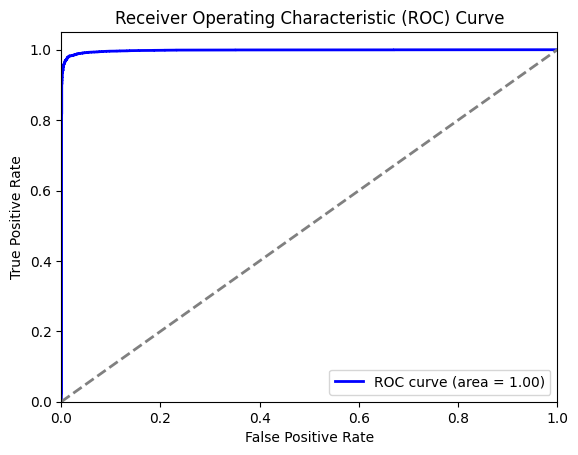

In [5]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, BatchNormalization, LeakyReLU
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create a Feedforward Neural Network (FFNN) model that processes 3D input
model = Sequential([
    Conv1D(64, kernel_size=3, padding='same', input_shape=(125, 128)),  # Conv1D on 3D (time, channels)
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Conv1D(32, kernel_size=3, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Flatten(),  # Flatten after Conv1D processing
    Dense(128),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Dense(64),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Dense(32),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

# Compile the model with lower learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_ffnn_model_dotprobe.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=True, mode='min', verbose=1)

# Train the model (without early stopping, but saving best weights)
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
model.load_weights('best_ffnn_model_dotprobe.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('ffnn_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'ffnn_training_history_dotprobe.npz'")

# Save final model's weights (optional, since best are restored)
model.save_weights('ffnn_model_dotprobe_final.weights.h5')
print("Final model weights saved to 'ffnn_model_dotprobe_final.weights.h5'")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **BNN With DVI**

Epoch 1/250
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7262 - loss: 0.5700
Epoch 1: val_loss improved from inf to 0.12259, saving model to best_bnn_model_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.7262 - loss: 0.5699 - val_accuracy: 0.9683 - val_loss: 0.1226
Epoch 2/250
1081/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9454 - loss: 0.1755
Epoch 2: val_loss improved from 0.12259 to 0.05901, saving model to best_bnn_model_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9455 - loss: 0.1751 - val_accuracy: 0.9853 - val_loss: 0.0590
Epoch 3/250
1083/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9762 - loss: 0.0771
Epoch 3: val_loss did not improve from 0.05901
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9762 - loss: 0.0775 - val_accuracy: 0.9728 - val_loss: 0.1484
Epoch 4/250
1082/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9760 - loss: 0.0731
Epoch 4: val_loss improved from 0.059

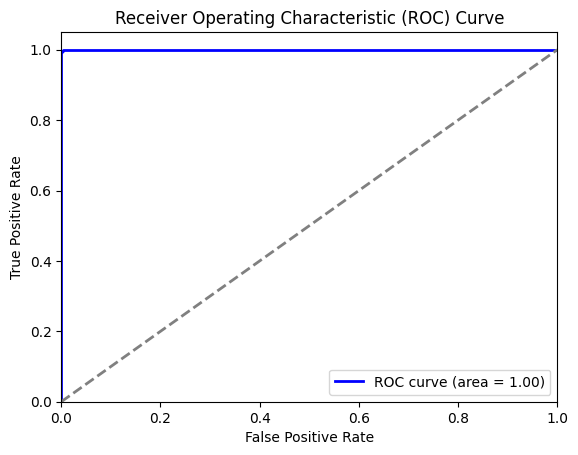

In [6]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Create a BNN model with Dropout Variational Inference that accepts 3D input
def create_bnn_model(input_shape):
    model = Sequential([
        Conv1D(64, kernel_size=3, padding='same', activation='relu', input_shape=input_shape),  # Conv1D on 3D
        Dropout(0.5),  # Dropout for Bayesian approximation
        Conv1D(32, kernel_size=3, padding='same', activation='relu'),
        Dropout(0.5),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Define input shape based on 3D data (timepoints, channels)
input_shape = (125, 128)

# Create the BNN model
model = create_bnn_model(input_shape)

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_bnn_model_dotprobe.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=True, mode='min', verbose=1)

# Train the model (without early stopping, but saving best weights)
history = model.fit(
    X_train, 
    y_train, 
    epochs=250, 
    batch_size=32, 
    validation_split=0.2,
    callbacks=[checkpoint]
)

# Restore the best weights after full training
model.load_weights('best_bnn_model_dotprobe.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('bnn_dvi_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'bnn_dvi_training_history_dotprobe.npz'")

# Save final model's weights (optional, since best are restored)
model.save_weights('bnn_model_dotprobe_final.weights.h5')
print("Final model weights saved to 'bnn_model_dotprobe_final.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **TCN**

2026-01-25 19:12:51.802850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769368372.184963      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769368372.296993      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769368373.204956      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769368373.205002      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769368373.205006      55 computation_placer.cc:177] computation placer alr

Epoch 1/50


I0000 00:00:1769368436.820729     127 service.cc:152] XLA service 0x7a992c018370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769368436.820764     127 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769368437.619230     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


  33/2184 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5080 - loss: 1.5223  

I0000 00:00:1769368443.533474     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

 Total params: 12,884,997 (49.15 MB)

 Trainable params: 4,294,657 (16.38 MB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 8,589,316 (32.77 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Accuracy: 0.9973435925620592
Confusion Matrix:
[[3285    2]
 [  27 7603]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3287
           1       1.00      1.00      1.00      7630

    accuracy                           1.00     10917
   macro avg       1.00      1.00      1.00     10917
weighted avg       1.00      1.00      1.00     10917



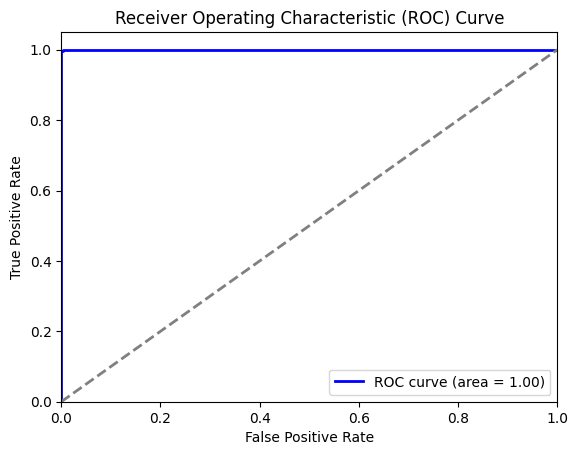

In [2]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Function to create a TCN block optimized for dot-probe task (deeper dilation for temporal patterns in ERP-like data)
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.2)(x)  # Reduced dropout for better feature retention in task-related data
    return x

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

# Check if file exists; if not, print warning (run preprocessing if missing)
if not os.path.exists(DATA_PATH):
    print(f"Warning: {DATA_PATH} not found. Run the preprocessing pipeline to generate it.")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create a TCN model optimized for dot-probe (more blocks for capturing ERP transients, higher filters for complexity)
inputs = Input(shape=(125, 128))  # (timepoints=125, channels=128)
x = TCN_block(inputs, filters=128, kernel_size=3, dilation_rate=1)  # Increased filters and kernel for task dynamics
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=2)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=4)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=8)  # Extra block for longer dependencies in probe task
x = Flatten()(x)
x = Dense(256, activation='relu')(x)  # Larger dense for better classification
x = Dropout(0.3)(x)  # Adjusted dropout
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model with lower learning rate for stability
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_tcn_model_dotprobe.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=True, mode='min', verbose=1)

# Train the model (increased epochs, smaller batch for memory, no early stopping)
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
model.load_weights('best_tcn_model_dotprobe.weights.h5')
print("Restored best weights from training.")

# Save training history (compressed npz, small size)
np.savez_compressed('tcn_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_training_history_dotprobe.npz' (small compressed file)")

# Save final model's weights (optional, since best are restored)
model.save_weights('tcn_model_dotprobe_final.weights.h5')
print("Final model weights saved to 'tcn_model_dotprobe_final.weights.h5' (single file, no extras)")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **GAN**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


0 [D loss: 0.7338342070579529, acc.: 59.375%] [G loss: 0.6729550361633301]
100 [D loss: 5.064361572265625, acc.: 30.25762939453125%] [G loss: 0.01005936972796917]
200 [D loss: 5.795070648193359, acc.: 30.04363250732422%] [G loss: 0.005072528962045908]
300 [D loss: 6.255148410797119, acc.: 29.758953094482422%] [G loss: 0.0033929897472262383]
400 [D loss: 6.56099796295166, acc.: 29.764514923095703%] [G loss: 0.0025489293038845062]
500 [D loss: 6.826933860778809, acc.: 29.905149459838867%] [G loss: 0.0020413228776305914]
600 [D loss: 7.039349555969238, acc.: 29.80129623413086%] [G loss: 0.0017022050451487303]
700 [D loss: 7.224095344543457, acc.: 29.713703155517578%] [G loss: 0.0014598347479477525]
800 [D loss: 7.391964912414551, acc.: 29.681161880493164%] [G loss: 0.0012778755044564605]
900 [D loss: 7.535101413726807, acc.: 29.6835994720459%] [G loss: 0.0011362177319824696]
GAN model weights saved to 'gan_model_dotprobe.weights.h5'
Generator and Discriminator weights saved
Epoch 1/50
   

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - accuracy: 0.8099 - loss: 0.6841 - val_accuracy: 0.8661 - val_loss: 0.3311
Epoch 2/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.8432 - loss: 0.4636 - val_accuracy: 0.8869 - val_loss: 0.2585
Epoch 3/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.8571 - loss: 0.3613 - val_accuracy: 0.8885 - val_loss: 0.2525
Epoch 4/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.8692 - loss: 0.3217 - val_accuracy: 0.8977 - val_loss: 0.2236
Epoch 5/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 32s 15ms/step - accuracy: 0.8794 - loss: 0.2859 - val_accuracy: 0.9086 - val_loss: 0.2064
Epoch 6/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.8951 - loss: 0.2380 - val_accuracy: 0.9158 - val_loss: 0.1988
Epoch 7/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.9039 - loss: 0.2274 - val_accuracy: 0.9235 - val_loss: 0.1804
Epoch 8/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.9161 - loss: 0.19

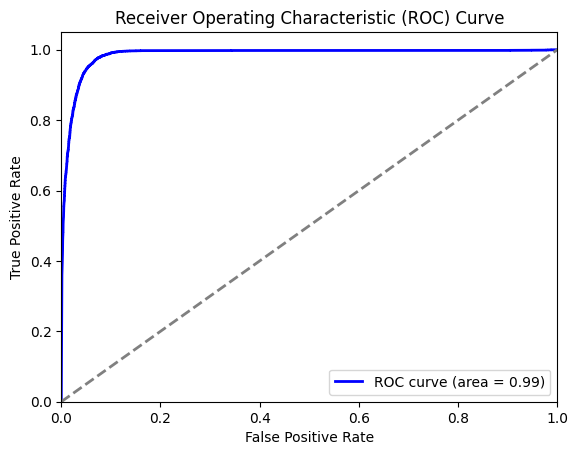

In [3]:
import os
import numpy as np
import gc
import h5py
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, LeakyReLU, Dropout, Input
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Enable mixed precision to reduce memory usage
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Flatten the 4D data to 2D for GAN (samples x (channels * timepoints))
X_flattened = X.reshape(X.shape[0], -1)

# Standardize the features
scaler = StandardScaler()
X_flattened = scaler.fit_transform(X_flattened).astype(np.float32)

# Get dimensions
num_samples = X_flattened.shape[0]
num_features = X_flattened.shape[1]

# Save real data and labels to HDF5 for memory efficiency
with h5py.File('real_data_main.h5', 'w') as f:
    f.create_dataset('data', data=X_flattened)
    f.create_dataset('labels', data=y.astype(np.int32))

# Free memory
del X_flattened, X, X_train_loaded, X_test_loaded
gc.collect()

# Open HDF5 file for real data
real_file = h5py.File('real_data_main.h5', 'r')
real_dset = real_file['data']
y_dset = real_file['labels']

# Define GAN components
latent_dim = 100  # Dimension of the latent space (noise input)

# Generator
def build_generator():
    model = Sequential()
    model.add(Dense(256, input_dim=latent_dim))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(512))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(1024))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dense(num_features, activation='tanh'))
    return model

# Discriminator
def build_discriminator():
    model = Sequential()
    model.add(Dense(512, input_shape=(num_features,)))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.4))
    model.add(Dense(256))
    model.add(LeakyReLU(alpha=0.2))
    model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid', dtype='float32'))  # Ensure float32 for stability in mixed precision
    return model

# Build and compile the discriminator
discriminator = build_discriminator()
discriminator.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5), loss='binary_crossentropy', metrics=['accuracy'])

# Build the generator
generator = build_generator()

# Create GAN by combining generator and discriminator
z = Input(shape=(latent_dim,))
generated_data = generator(z)
discriminator.trainable = False  # Freeze the discriminator during GAN training
validity = discriminator(generated_data)
gan = Model(z, validity)
gan.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5), loss='binary_crossentropy')

# Training parameters (reduced batch size for memory efficiency)
epochs = 1000
batch_size = 32
sample_interval = 100
gen_batch_size = 128  # Batch size for synthetic generation to balance speed and memory

# Labels for real and fake data
real = np.ones((batch_size, 1))
fake = np.zeros((batch_size, 1))

# Training the GAN
for epoch in range(epochs):
    
    # Train Discriminator
    idx = np.random.choice(num_samples, batch_size, replace=False)  # Unique indices
    idx = np.sort(idx)  # Sort for h5py fancy indexing
    real_data = real_dset[idx]
    
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    generated_data_batch = generator.predict(noise, verbose=0)
    
    d_loss_real = discriminator.train_on_batch(real_data, real)
    d_loss_fake = discriminator.train_on_batch(generated_data_batch, fake)
    d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)
    
    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, latent_dim))
    g_loss = gan.train_on_batch(noise, real)
    
    # Print progress
    if epoch % sample_interval == 0:
        print(f"{epoch} [D loss: {d_loss[0]}, acc.: {100*d_loss[1]}%] [G loss: {g_loss}]")
    
    # Periodic garbage collection
    if epoch % 100 == 0:
        gc.collect()

# Save GAN weights
gan.save_weights('gan_model_dotprobe_main.weights.h5')
print("GAN model weights saved to 'gan_model_dotprobe.weights.h5'")

# Save Generator and Discriminator separately
generator.save_weights('generator_dotprobe_main.weights.h5')
discriminator.save_weights('discriminator_dotprobe_main.weights.h5')
print("Generator and Discriminator weights saved")

# Generate synthetic data in batches and save to HDF5
with h5py.File('synthetic_data_main.h5', 'w') as f:
    synth_dset = f.create_dataset('data', shape=(num_samples, num_features), dtype='float32')
    
    for start in range(0, num_samples, gen_batch_size):
        end = min(start + gen_batch_size, num_samples)
        this_batch = end - start
        noise = np.random.normal(0, 1, (this_batch, latent_dim))
        synth_batch = generator.predict(noise, verbose=0)
        synth_dset[start:end] = synth_batch
        gc.collect()

# Open HDF5 file for synthetic data
synth_file = h5py.File('synthetic_data_main.h5', 'r')
synth_dset = synth_file['data']

# Prepare indices for combined dataset (real + synthetic)
len_real = num_samples
len_synth = num_samples
total = len_real + len_synth
indices = np.arange(total)
np.random.seed(42)
np.random.shuffle(indices)

# Calculate split sizes
n_test = int(0.2 * total)
test_indices = indices[:n_test]
train_val_indices = indices[n_test:]
n_train_val = len(train_val_indices)
n_val = int(0.2 * n_train_val)
train_indices = train_val_indices[:n_train_val - n_val]
val_indices = train_val_indices[n_train_val - n_val:]

# Function to create generator for dataset
def make_generator(indices_list):
    def gen():
        for idx in indices_list:
            if idx < len_real:
                x = real_dset[idx]
                lbl = y_dset[idx]
            else:
                x = synth_dset[idx - len_real]
                lbl = 0
            yield x, lbl
    return gen

# Create tf.data.Datasets
batch_size_finetune = 32

train_ds = tf.data.Dataset.from_generator(
    make_generator(train_indices),
    output_types=(tf.float32, tf.int32),
    output_shapes=((num_features,), ())
).batch(batch_size_finetune).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_generator(
    make_generator(val_indices),
    output_types=(tf.float32, tf.int32),
    output_shapes=((num_features,), ())
).batch(batch_size_finetune).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    make_generator(test_indices),
    output_types=(tf.float32, tf.int32),
    output_shapes=((num_features,), ())
).batch(batch_size_finetune).prefetch(tf.data.AUTOTUNE)

# Train the discriminator as a binary classifier
discriminator.trainable = True  # Unfreeze the discriminator for fine-tuning
discriminator.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5), loss='binary_crossentropy', metrics=['accuracy'])
history = discriminator.fit(train_ds, epochs=50, validation_data=val_ds, verbose=1)

# Save training history (compressed npz, small size)
np.savez_compressed('gan_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'gan_training_history_dotprobe.npz'")

# Make predictions in batches to avoid OOM
y_pred_prob = []
y_test_list = []

for x, y_batch in test_ds:
    pred = discriminator.predict(x, verbose=0)
    y_pred_prob.append(pred.ravel())
    y_test_list.append(y_batch.numpy())

y_pred_prob = np.concatenate(y_pred_prob)
y_test = np.concatenate(y_test_list)

# Evaluate performance
y_pred = (y_pred_prob > 0.5).astype(int)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# Close HDF5 files
real_file.close()
synth_file.close()

# **DNN**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5832 - loss: 0.8022
Epoch 1: val_loss improved from inf to 0.59402, saving model to best_dnn_model_dotprobe_main.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.5832 - loss: 0.8022 - val_accuracy: 0.7242 - val_loss: 0.5940
Epoch 2/50
1088/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5793 - loss: 0.7073
Epoch 2: val_loss improved from 0.59402 to 0.46635, saving model to best_dnn_model_dotprobe_main.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5795 - loss: 0.7071 - val_accuracy: 0.7922 - val_loss: 0.4664
Epoch 3/50
1083/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8118 - loss: 0.4342
Epoch 3: val_loss improved from 0.46635 to 0.16593, saving model to best_dnn_model_dotprobe_main.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8122 - loss: 0.4335 - val_accuracy: 0.9442 - val_loss: 0.1659
Epoch 4/50
1088/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - 

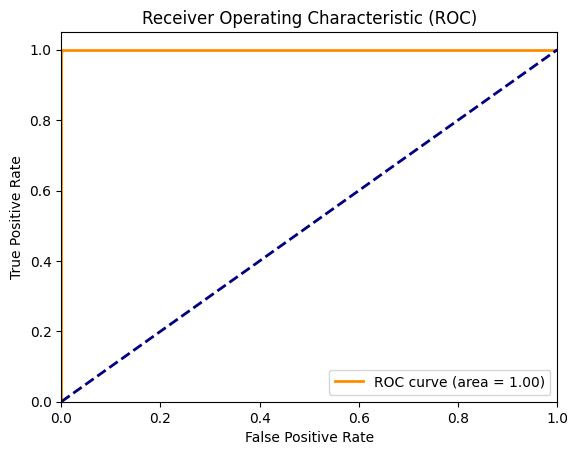

In [3]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Dropout, BatchNormalization, LeakyReLU, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Build the improved DNN model that processes 3D input
model = Sequential([
    Conv1D(128, kernel_size=3, padding='same', input_shape=(125, 128)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Conv1D(64, kernel_size=3, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Conv1D(32, kernel_size=3, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Flatten(),  # Flatten after Conv1D processing
    Dense(512),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    Dense(256),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    Dense(128),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    Dense(64),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    Dense(32),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Sigmoid activation for binary classification
])

# Compile the model with a lower learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_dnn_model_dotprobe_main.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=True, mode='min', verbose=1)

# Train the model (reduced epochs, no early stopping, but saving best weights)
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
model.load_weights('best_dnn_model_dotprobe_main.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('dnn_training_history_dotprobe_enhanced_main.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'dnn_training_history_dotprobe_enhanced_main.npz'")

# Save final model's weights (optional, since best are restored)
model.save_weights('dnn_model_dotprobe_enhanced_final_main.weights.h5')
print("Model weights saved to 'dnn_model_dotprobe_enhanced_final_main.weights.h5'")

# Evaluate the model
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC Curve and AUC
# fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
# roc_auc = auc(fpr, tpr)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)


# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

# **CNN**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7945 - loss: 0.4968
Epoch 1: val_loss improved from inf to 0.27082, saving model to best_cnn_model_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 30s 11ms/step - accuracy: 0.7946 - loss: 0.4967 - val_accuracy: 0.9474 - val_loss: 0.2708
Epoch 2/50
2182/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9621 - loss: 0.1314
Epoch 2: val_loss improved from 0.27082 to 0.16680, saving model to best_cnn_model_dotprobe.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.9621 - loss: 0.1314 - val_accuracy: 0.9763 - val_loss: 0.1668
Epoch 3/50
2178/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9862 - loss: 0.0595
Epoch 3: val_loss did not improve from 0.16680
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.9862 - loss: 0.0595 - val_accuracy: 0.9587 - val_loss: 0.1866
Epoch 4/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9902 - loss: 0.0435
Epoch 4: val_loss improved from 0.1668

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 123, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 123, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 123, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 61, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 61, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 59, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 59, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 59, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 29, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 29, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 55680)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     7,127,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,440,133 (81.79 MB)

 Trainable params: 7,146,561 (27.26 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 14,293,124 (54.52 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Accuracy: 0.9978931941009435
Confusion Matrix:
[[3283    4]
 [  19 7611]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3287
           1       1.00      1.00      1.00      7630

    accuracy                           1.00     10917
   macro avg       1.00      1.00      1.00     10917
weighted avg       1.00      1.00      1.00     10917



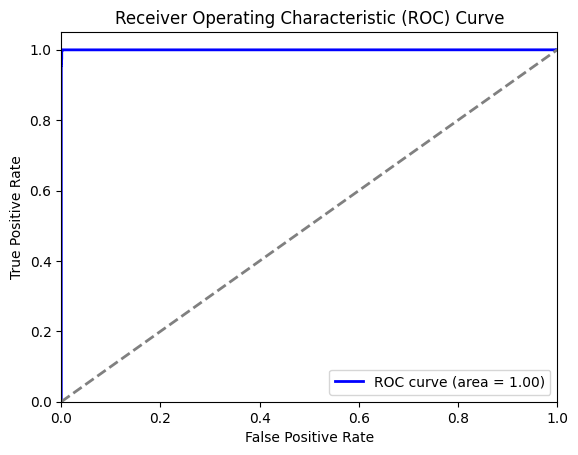

In [4]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv2D (treat time as height, channels as width)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Add channel dimension for Conv2D: (samples, timepoints, channels, 1)
X = np.expand_dims(X, axis=-1)  # Now (samples, timepoints=125, channels=128, 1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 4D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128, 1)
X_test = X_test_flat.reshape(n_test, 125, 128, 1)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create a CNN model that processes 4D input (samples, time, channels, 1)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(125, 128, 1)),  # Conv2D on 4D (time, channels, 1)
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model with lower learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_cnn_model_dotprobe.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=True, mode='min', verbose=1)

# Train the model (without early stopping, but saving best weights)
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
model.load_weights('best_cnn_model_dotprobe.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('cnn_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'cnn_training_history_dotprobe.npz'")

# Save final model's weights (optional, since best are restored)
model.save_weights('cnn_model_dotprobe_final.weights.h5')
print("Final model weights saved to 'cnn_model_dotprobe_final.weights.h5'")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **MLPNN**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5827 - loss: 0.7016
Epoch 1: val_loss improved from inf to 0.28914, saving model to best_mlpnn_model_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5828 - loss: 0.7015 - val_accuracy: 0.8680 - val_loss: 0.2891
Epoch 2/50
1089/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9355 - loss: 0.1732
Epoch 2: val_loss improved from 0.28914 to 0.03686, saving model to best_mlpnn_model_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9355 - loss: 0.1731 - val_accuracy: 0.9872 - val_loss: 0.0369
Epoch 3/50
1088/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9738 - loss: 0.0730
Epoch 3: val_loss improved from 0.03686 to 0.02601, saving model to best_mlpnn_model_dotprobe.weights.h5
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9738 - loss: 0.0730 - val_accuracy: 0.9920 - val_loss: 0.0260
Epoch 4/50
1085/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 125, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 125, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 125, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 125, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 125, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 125, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 125, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 125, 32)        │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 125, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_22 (LeakyReLU)      │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 125, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │         4,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 699,269 (2.67 MB)

 Trainable params: 232,769 (909.25 KB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 465,540 (1.78 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Accuracy: 0.9979847943574242
Confusion Matrix:
[[3282    5]
 [  17 7613]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      3287
           1       1.00      1.00      1.00      7630

    accuracy                           1.00     10917
   macro avg       1.00      1.00      1.00     10917
weighted avg       1.00      1.00      1.00     10917



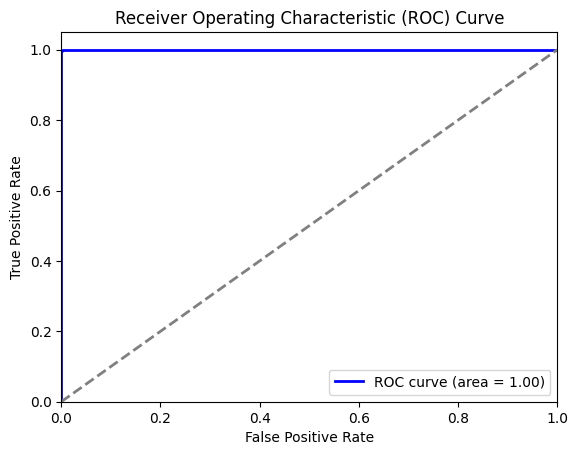

In [5]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create a Multilayer Perceptron (MLP) model that processes 3D input
model = Sequential([
    Conv1D(256, kernel_size=3, padding='same', input_shape=(125, 128)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Conv1D(128, kernel_size=3, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Conv1D(64, kernel_size=3, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Conv1D(32, kernel_size=3, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Flatten(),  # Flatten after Conv1D processing
    Dense(1, activation='sigmoid')
])

# Compile the model with lower learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_mlpnn_model_dotprobe.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=True, mode='min', verbose=1)

# Train the model (without early stopping, but saving best weights)
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
model.load_weights('best_mlpnn_model_dotprobe.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('mlpnn_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'mlpnn_training_history_dotprobe.npz'")

# Save final model's weights (optional, since best are restored)
model.save_weights('mlpnn_model_dotprobe_final.weights.h5')
print("Final model weights saved to 'mlpnn_model_dotprobe_final.weights.h5'")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **LSTM**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
2182/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5558 - loss: 0.8299
Epoch 1: val_loss improved from inf to 0.46081, saving model to best_lstm_model_dotprobe_main.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 55s 23ms/step - accuracy: 0.5558 - loss: 0.8298 - val_accuracy: 0.7821 - val_loss: 0.4608
Epoch 2/50
2182/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7101 - loss: 0.5711
Epoch 2: val_loss improved from 0.46081 to 0.25411, saving model to best_lstm_model_dotprobe_main.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.7101 - loss: 0.5710 - val_accuracy: 0.9071 - val_loss: 0.2541
Epoch 3/50
2182/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9003 - loss: 0.2948
Epoch 3: val_loss improved from 0.25411 to 0.09404, saving model to best_lstm_model_dotprobe_main.weights.h5
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 49s 22ms/step - accuracy: 0.9003 - loss: 0.2948 - val_accuracy: 0.9739 - val_loss: 0.0940
Epoch 4/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 21

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 125, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 125, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 125, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 125, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 125, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 125, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 589,061 (2.25 MB)

 Trainable params: 196,161 (766.25 KB)

 Non-trainable params: 576 (2.25 KB)

 Optimizer params: 392,324 (1.50 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Accuracy: 0.9912979756343318
Confusion Matrix:
[[3263   24]
 [  71 7559]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3287
           1       1.00      0.99      0.99      7630

    accuracy                           0.99     10917
   macro avg       0.99      0.99      0.99     10917
weighted avg       0.99      0.99      0.99     10917



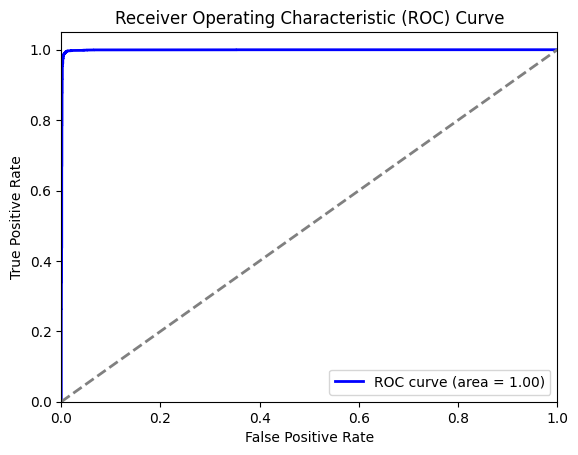

In [7]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for LSTM (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Replace any remaining NaN/Inf with 0 to ensure clean inputs
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create an LSTM model that processes 3D input
model = Sequential([
    LSTM(128, activation='tanh', return_sequences=True, input_shape=(125, 128)),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(64, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(32, activation='tanh'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

# Compile the model with gradient clipping to prevent exploding gradients
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_lstm_model_dotprobe_main.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=True, mode='min', verbose=1)

# Train the model (without early stopping, but saving best weights)
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
model.load_weights('best_lstm_model_dotprobe_main.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('lstm_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'lstm_training_history_dotprobe_main.npz'")

# Save final model's weights (optional, since best are restored)
model.save_weights('lstm_model_dotprobe_final_main.weights.h5')
print("Final model weights saved to 'lstm_model_dotprobe_final_main.weights.h5'")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **ALL PLOTS FOR DL RAW CSV DATA**

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, LSTM, Conv1D, Conv2D,
                                     MaxPooling2D, Flatten, LeakyReLU, Input, Activation, SpatialDropout1D)

# Config
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

# Load test data
data = np.load(DATA_PATH, allow_pickle=True)
X_test = data['X_test']
y_test = data['y_test']

# Squeeze to 3D (samples, channels, timepoints)
X_test = np.squeeze(X_test, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for models expecting that format
X_test_3d = np.swapaxes(X_test, 1, 2)  # (samples, timepoints=125, channels=128)

# For CNN: Add channel dimension (samples, timepoints, channels, 1)
X_test_4d = np.expand_dims(X_test_3d, axis=-1)

# For flattened models: Flatten to 2D
X_test_flat = X_test_3d.reshape(X_test.shape[0], -1)

# Standardize X_test (flatten temporarily for scaling)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_test_flat_scaled = scaler.fit_transform(X_test_flat)  # Fit on test for standalone; use train scaler in practice

# Reshape back for 3D/4D if needed (but scaling is per-feature, so apply to flat and reshape)
X_test_3d_scaled = X_test_flat_scaled.reshape(X_test_3d.shape)
X_test_4d_scaled = np.expand_dims(X_test_3d_scaled, axis=-1)

time_steps = X_test_3d.shape[1]  # 125
channels = X_test_3d.shape[2]  # 128

# Dynamic model list (adapt build_func for each model)
model_configs = [
    {'name': 'TCN', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/tcn_model_dotprobe_final.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/tcn_training_history_dotprobe.npz'), 'is_3d': True, 'build_func': lambda: (
        inputs := Input(shape=(time_steps, channels)),
        x := Conv1D(128, 3, padding='causal', dilation_rate=1)(inputs),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.2)(x),
        x := Conv1D(128, 3, padding='causal', dilation_rate=2)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.2)(x),
        x := Conv1D(128, 3, padding='causal', dilation_rate=4)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.2)(x),
        x := Conv1D(128, 3, padding='causal', dilation_rate=8)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.2)(x),
        x := Flatten()(x),
        x := Dense(256, activation='relu')(x),
        x := Dropout(0.3)(x),
        outputs := Dense(1, activation='sigmoid')(x),
        Model(inputs=inputs, outputs=outputs)
    )[-1]},
    {'name': 'GAN', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/discriminator_dotprobe_main.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/gan_training_history_dotprobe.npz'), 'is_3d': False, 'build_func': lambda: Sequential([
        Dense(512, input_shape=(time_steps * channels,)), LeakyReLU(alpha=0.2), Dropout(0.4), Dense(256), LeakyReLU(alpha=0.2), Dropout(0.4), Dense(1, activation='sigmoid')])},
    {'name': 'FFNN', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/ffnn_model_dotprobe_final.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/ffnn_training_history_dotprobe.npz'), 'is_3d': True, 'build_func': lambda: Sequential([
        Conv1D(64, kernel_size=3, padding='same', input_shape=(time_steps, channels)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Conv1D(32, kernel_size=3, padding='same'),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Flatten(),
        Dense(128),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Dense(64),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Dense(32),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Dense(1, activation='sigmoid')
    ])},
    {'name': 'BNN with DVI', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/bnn_model_dotprobe_final.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/bnn_dvi_training_history_dotprobe.npz'), 'is_3d': True, 'build_func': lambda: Sequential([
        Conv1D(64, kernel_size=3, padding='same', activation='relu', input_shape=(time_steps, channels)),
        Dropout(0.5),
        Conv1D(32, kernel_size=3, padding='same', activation='relu'),
        Dropout(0.5),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])},
    {'name': 'CNN', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/cnn_model_dotprobe_final.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/cnn_training_history_dotprobe.npz'), 'is_3d': True, 'build_func': lambda: Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(time_steps, channels, 1)),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        Flatten(),
        Dense(128, activation='tanh'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])},
    {'name': 'DNN', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/dnn_model_dotprobe_enhanced_final_main.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/dnn_training_history_dotprobe_enhanced_main.npz'), 'is_3d': True, 'build_func': lambda: Sequential([
        Conv1D(128, kernel_size=3, padding='same', input_shape=(time_steps, channels)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Conv1D(64, kernel_size=3, padding='same'),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Conv1D(32, kernel_size=3, padding='same'),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Flatten(),
        Dense(512),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        Dense(256),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        Dense(128),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        Dense(64),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        Dense(32),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])},
    {'name': 'MLPNN', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/mlpnn_model_dotprobe_final.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/mlpnn_training_history_dotprobe.npz'), 'is_3d': True, 'build_func': lambda: Sequential([
        Conv1D(256, kernel_size=3, padding='same', input_shape=(time_steps, channels)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Conv1D(128, kernel_size=3, padding='same'),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Conv1D(64, kernel_size=3, padding='same'),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Conv1D(32, kernel_size=3, padding='same'),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Flatten(),
        Dense(1, activation='sigmoid')
    ])},
    {'name': 'LSTM', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/lstm_model_dotprobe_final_main.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/lstm_training_history_dotprobe.npz'), 'is_3d': True, 'build_func': lambda: Sequential([
        LSTM(128, activation='tanh', return_sequences=True, input_shape=(time_steps, channels)),
        BatchNormalization(),
        Dropout(0.3),
        
        LSTM(64, activation='tanh', return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),
        
        LSTM(32, activation='tanh'),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(1, activation='sigmoid')
    ])}
]

metrics = {}
histories = {}
for cfg in model_configs:
    name = cfg['name']
    weights_path = cfg['weights']
    history_path = cfg['history']
    
    if not os.path.exists(weights_path):
        print(f"Skipping {name}: Weights not found")
        continue
    
    model = cfg['build_func']()
    model.load_weights(weights_path)
    
    if name == 'CNN':
        test_data = np.expand_dims(X_test_3d, axis=-1)  # Add channel for CNN
    else:
        test_data = X_test_3d
    
    y_pred_prob = model.predict(test_data, verbose=0).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    metrics[name] = {
        'acc': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred),
        'fpr': roc_curve(y_test, y_pred_prob)[0],
        'tpr': roc_curve(y_test, y_pred_prob)[1],
        'auc': roc_auc_score(y_test, y_pred_prob)
    }
    
    if os.path.exists(history_path):
        h = np.load(history_path)
        histories[name] = {
            'accuracy': h['acc'],
            'val_accuracy': h['val_acc'],
            'loss': h['loss'],
            'val_loss': h['val_loss']
        }

# Plots if metrics available
if metrics:
    names = list(metrics.keys())
    
    # 1. Classification Report Plot (Table)
    fig, ax = plt.subplots(figsize=(12, len(names)*0.5 + 2))
    ax.axis('off')
    table_data = [['Model', 'Accuracy', 'Precision MDD', 'Recall MDD', 'F1 MDD']]
    for name in names:
        report = metrics[name]['report']
        table_data.append([name, f"{metrics[name]['acc']:.4f}", f"{report.get('1', {}).get('precision', 0):.4f}", f"{report.get('1', {}).get('recall', 0):.4f}", f"{report.get('1', {}).get('f1-score', 0):.4f}"])
    ax.table(cellText=table_data, colWidths=[0.2]*5, loc='center')
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_classification_report.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 2. Confusion Matrix Plot (Grid)
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    axs = axs.ravel()
    for i, name in enumerate(names):
        sns.heatmap(metrics[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=axs[i])
        axs[i].set_title(name)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_confusion_matrix.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 3. ROC-AUC Plot
    plt.figure(figsize=(10, 8))
    for name in names:
        plt.plot(metrics[name]['fpr'], metrics[name]['tpr'], label=f'{name} (AUC = {metrics[name]["auc"]:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC-AUC Curves')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_roc_auc.png'), bbox_inches='tight')
    plt.show()
    plt.close()

# Plots if histories available
if histories:
    names_hist = list(histories.keys())
    
    # 4. Train-Val Accuracy vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['accuracy'], label=f'{name} Train Acc')
        plt.plot(histories[name]['val_accuracy'], '--', label=f'{name} Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Train-Val Accuracy vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_train_val_accuracy.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 5. Train-Val Loss vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['loss'], label=f'{name} Train Loss')
        plt.plot(histories[name]['val_loss'], '--', label=f'{name} Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train-Val Loss vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_train_val_loss.png'), bbox_inches='tight')
    plt.show()
    plt.close()

print("All plots generated.")

2026-01-26 12:06:22.249735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769429182.447011      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769429182.504538      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769429182.983714      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769429182.983751      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769429182.983754      55 computation_placer.cc:177] computation placer alr

ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 125, 128), dtype=float32). Expected shape (None, 16000), but input has incompatible shape (32, 125, 128)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 125, 128), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, LSTM, Conv1D, Conv2D,
                                     MaxPooling2D, Flatten, LeakyReLU, Input, Activation, SpatialDropout1D)

# Config
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results" or "/kaggle/working/"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

# Load test data
data = np.load(DATA_PATH, allow_pickle=True)
X_test = data['X_test']
y_test = data['y_test']

# Squeeze to 3D (samples, channels, timepoints)
X_test = np.squeeze(X_test, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for models expecting that format
X_test_3d = np.swapaxes(X_test, 1, 2)  # (samples, timepoints=125, channels=128)

# For CNN: Add channel dimension (samples, timepoints, channels, 1)
X_test_4d = np.expand_dims(X_test_3d, axis=-1)

# For flattened models: Flatten to 2D
X_test_flat = X_test_3d.reshape(X_test.shape[0], -1)

# Standardize X_test (flatten temporarily for scaling)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_test_flat_scaled = scaler.fit_transform(X_test_flat)  # Fit on test for standalone; use train scaler in practice

# Reshape back for 3D/4D if needed (but scaling is per-feature, so apply to flat and reshape)
X_test_3d_scaled = X_test_flat_scaled.reshape(X_test_3d.shape)
X_test_4d_scaled = np.expand_dims(X_test_3d_scaled, axis=-1)

time_steps = X_test_3d.shape[1]  # 125
channels = X_test_3d.shape[2]  # 128

# Dynamic model list (adapt build_func for each model)
model_configs = [
    {'name': 'TCN', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/tcn_model_dotprobe_final.weights.h5'), 'history': os.path.join(OUTPUT_DIR,  '/kaggle/working/tcn_training_history_dotprobe.npz'), 'is_3d': True, 'build_func': lambda: (
        inputs := Input(shape=(time_steps, channels)),
        x := Conv1D(128, 3, padding='causal', dilation_rate=1)(inputs),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.2)(x),
        x := Conv1D(128, 3, padding='causal', dilation_rate=2)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.2)(x),
        x := Conv1D(128, 3, padding='causal', dilation_rate=4)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.2)(x),
        x := Conv1D(128, 3, padding='causal', dilation_rate=8)(x),
        x := BatchNormalization()(x),
        x := Activation('relu')(x),
        x := SpatialDropout1D(0.2)(x),
        x := Flatten()(x),
        x := Dense(256, activation='relu')(x),
        x := Dropout(0.3)(x),
        outputs := Dense(1, activation='sigmoid')(x),
        Model(inputs=inputs, outputs=outputs)
    )[-1]},
    {'name': 'GAN', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/discriminator_dotprobe_main.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/gan_training_history_dotprobe.npz'), 'is_3d': False, 'build_func': lambda: Sequential([
        Dense(512, input_shape=(time_steps * channels,)), LeakyReLU(alpha=0.2), Dropout(0.4), Dense(256), LeakyReLU(alpha=0.2), Dropout(0.4), Dense(1, activation='sigmoid')])},
    {'name': 'FFNN', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/ffnn_model_dotprobe_final.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/ffnn_training_history_dotprobe.npz'), 'is_3d': True, 'build_func': lambda: Sequential([
        Conv1D(64, kernel_size=3, padding='same', input_shape=(time_steps, channels)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Conv1D(32, kernel_size=3, padding='same'),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Flatten(),
        Dense(128),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Dense(64),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Dense(32),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Dense(1, activation='sigmoid')
    ])},
    {'name': 'BNN with DVI', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/bnn_model_dotprobe_final.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/bnn_dvi_training_history_dotprobe.npz'), 'is_3d': True, 'build_func': lambda: Sequential([
        Conv1D(64, kernel_size=3, padding='same', activation='relu', input_shape=(time_steps, channels)),
        Dropout(0.5),
        Conv1D(32, kernel_size=3, padding='same', activation='relu'),
        Dropout(0.5),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])},
    {'name': 'CNN', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/cnn_model_dotprobe_final.weights.h5' ), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/cnn_training_history_dotprobe.npz'), 'is_3d': True, 'build_func': lambda: Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(time_steps, channels, 1)),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D((2, 2)),
        Dropout(0.25),
        
        Flatten(),
        Dense(128, activation='tanh'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])},
    {'name': 'DNN', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/dnn_model_dotprobe_enhanced_final_main.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/dnn_training_history_dotprobe_enhanced_main.npz'), 'is_3d': True, 'build_func': lambda: Sequential([
        Conv1D(128, kernel_size=3, padding='same', input_shape=(time_steps, channels)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Conv1D(64, kernel_size=3, padding='same'),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Conv1D(32, kernel_size=3, padding='same'),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Flatten(),
        Dense(512),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        Dense(256),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        Dense(128),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        Dense(64),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        Dense(32),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])},
    {'name': 'MLPNN', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/mlpnn_model_dotprobe_final.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/mlpnn_training_history_dotprobe.npz'), 'is_3d': True, 'build_func': lambda: Sequential([
        Conv1D(256, kernel_size=3, padding='same', input_shape=(time_steps, channels)),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Conv1D(128, kernel_size=3, padding='same'),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Conv1D(64, kernel_size=3, padding='same'),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Conv1D(32, kernel_size=3, padding='same'),
        BatchNormalization(),
        LeakyReLU(alpha=0.1),
        Dropout(0.3),
        
        Flatten(),
        Dense(1, activation='sigmoid')
    ])},
    {'name': 'LSTM', 'weights': os.path.join(OUTPUT_DIR, '/kaggle/working/lstm_model_dotprobe_final_main.weights.h5'), 'history': os.path.join(OUTPUT_DIR, '/kaggle/working/lstm_training_history_dotprobe.npz'), 'is_3d': True, 'build_func': lambda: Sequential([
        LSTM(128, activation='tanh', return_sequences=True, input_shape=(time_steps, channels)),
        BatchNormalization(),
        Dropout(0.3),
        
        LSTM(64, activation='tanh', return_sequences=True),
        BatchNormalization(),
        Dropout(0.3),
        
        LSTM(32, activation='tanh'),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        
        Dense(1, activation='sigmoid')
    ])}
]

metrics = {}
histories = {}
for cfg in model_configs:
    name = cfg['name']
    weights_path = cfg['weights']
    history_path = cfg['history']
    
    if not os.path.exists(weights_path):
        print(f"Skipping {name}: Weights not found")
        continue
    
    model = cfg['build_func']()
    model.load_weights(weights_path)
    
    if name == 'CNN':
        test_data = X_test_4d_scaled
    else:
        test_data = X_test_3d_scaled
    
    y_pred_prob = model.predict(test_data, verbose=0).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    metrics[name] = {
        'acc': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred),
        'fpr': roc_curve(y_test, y_pred_prob)[0],
        'tpr': roc_curve(y_test, y_pred_prob)[1],
        'auc': roc_auc_score(y_test, y_pred_prob)
    }
    
    if os.path.exists(history_path):
        h = np.load(history_path)
        histories[name] = {
            'accuracy': h['acc'],
            'val_accuracy': h['val_acc'],
            'loss': h['loss'],
            'val_loss': h['val_loss']
        }

# Plots if metrics available
if metrics:
    names = list(metrics.keys())
    
    # 1. Classification Report Plot (Table)
    fig, ax = plt.subplots(figsize=(12, len(names)*0.5 + 2))
    ax.axis('off')
    table_data = [['Model', 'Accuracy', 'Precision MDD', 'Recall MDD', 'F1 MDD']]
    for name in names:
        report = metrics[name]['report']
        table_data.append([name, f"{metrics[name]['acc']:.4f}", f"{report.get('1', {}).get('precision', 0):.4f}", f"{report.get('1', {}).get('recall', 0):.4f}", f"{report.get('1', {}).get('f1-score', 0):.4f}"])
    ax.table(cellText=table_data, colWidths=[0.2]*5, loc='center')
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_classification_report.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 2. Confusion Matrix Plot (Grid)
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    axs = axs.ravel()
    for i, name in enumerate(names):
        sns.heatmap(metrics[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=axs[i])
        axs[i].set_title(name)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_confusion_matrix.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 3. ROC-AUC Plot
    plt.figure(figsize=(10, 8))
    for name in names:
        plt.plot(metrics[name]['fpr'], metrics[name]['tpr'], label=f'{name} (AUC = {metrics[name]["auc"]:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC-AUC Curves')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_roc_auc.png'), bbox_inches='tight')
    plt.show()
    plt.close()

# Plots if histories available
if histories:
    names_hist = list(histories.keys())
    
    # 4. Train-Val Accuracy vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['accuracy'], label=f'{name} Train Acc')
        plt.plot(histories[name]['val_accuracy'], '--', label=f'{name} Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Train-Val Accuracy vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_train_val_accuracy.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 5. Train-Val Loss vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['loss'], label=f'{name} Train Loss')
        plt.plot(histories[name]['val_loss'], '--', label=f'{name} Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train-Val Loss vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_train_val_loss.png'), bbox_inches='tight')
    plt.show()
    plt.close()

print("All plots generated.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 125, 128), dtype=float32). Expected shape (None, 16000), but input has incompatible shape (32, 125, 128)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 125, 128), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative

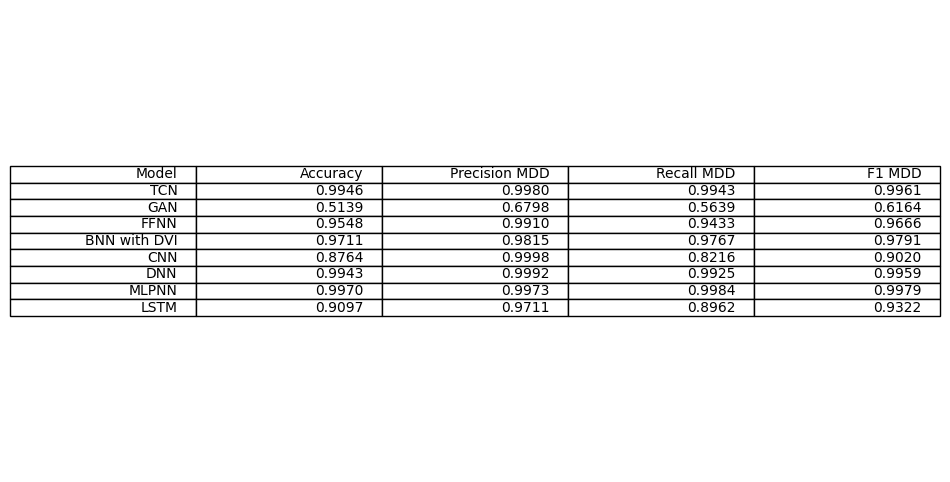

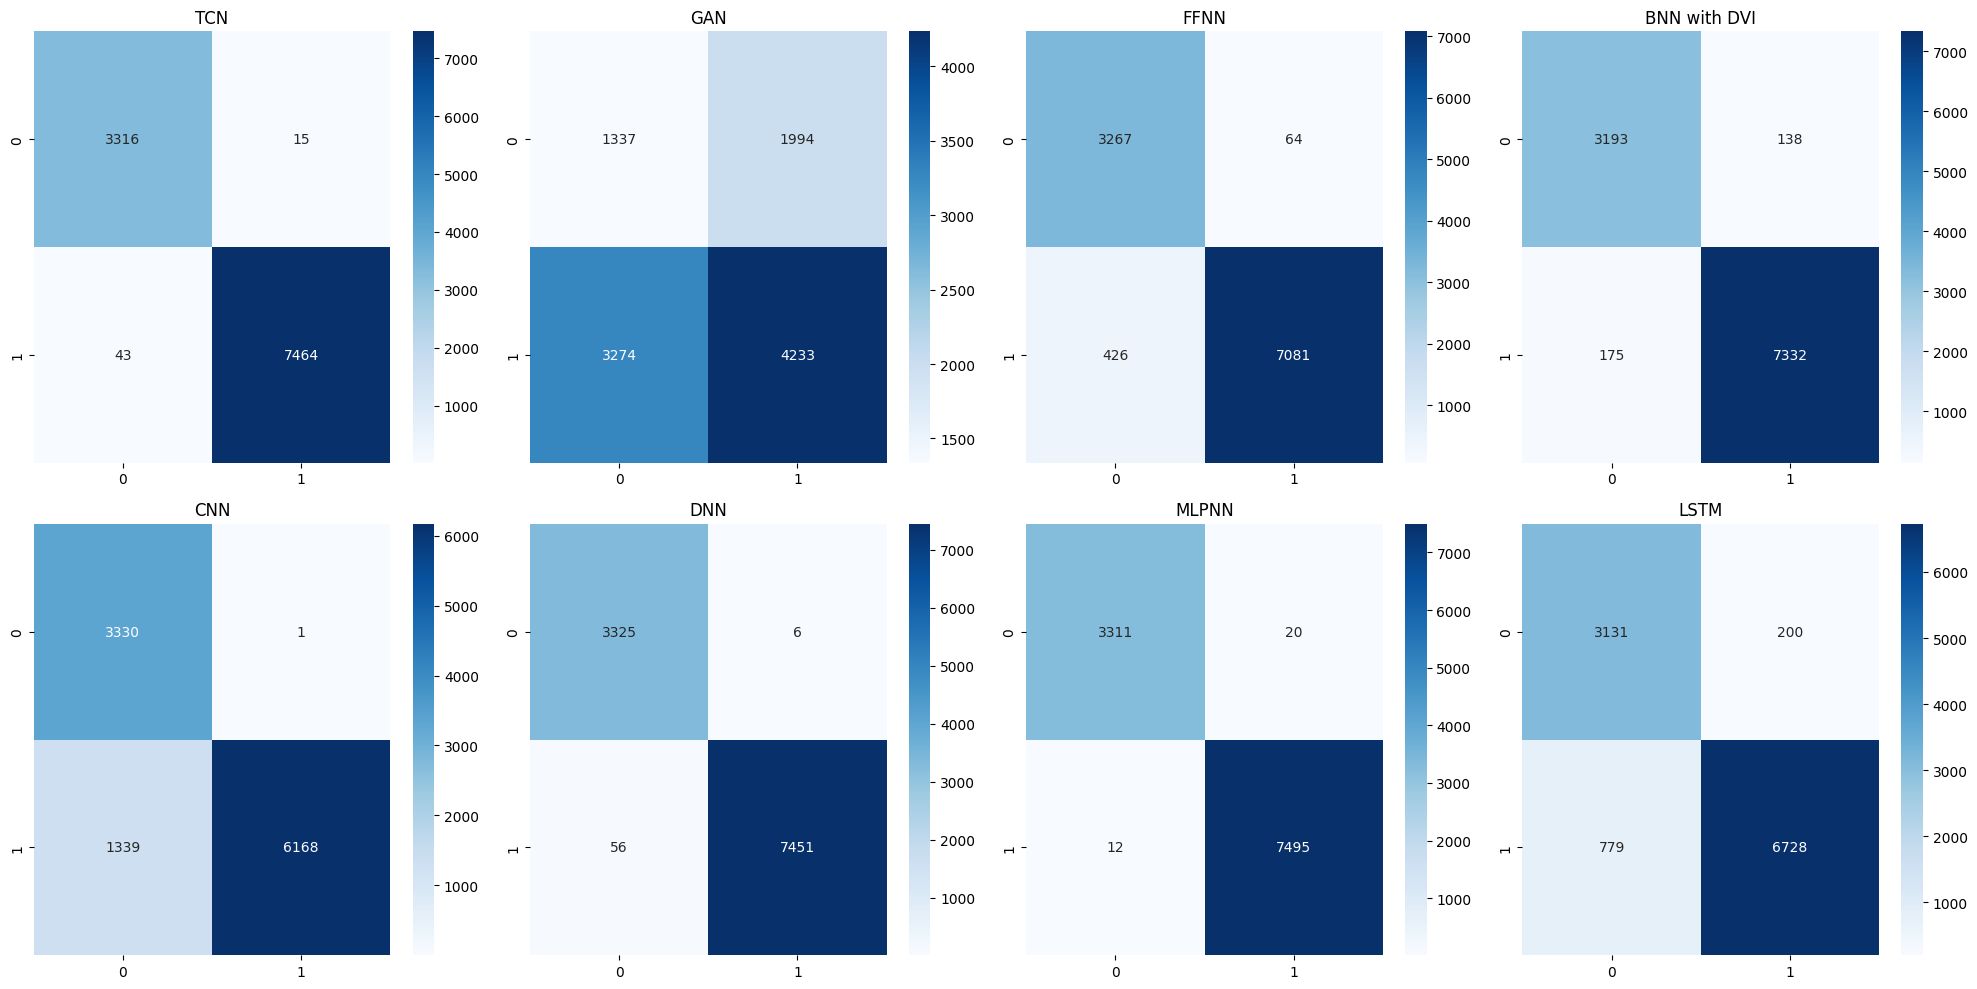

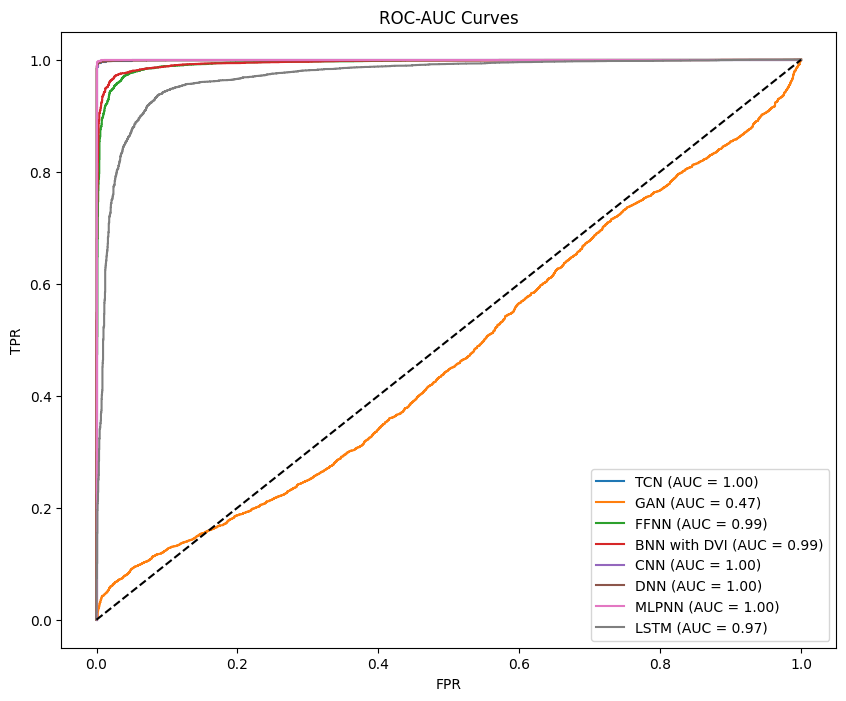

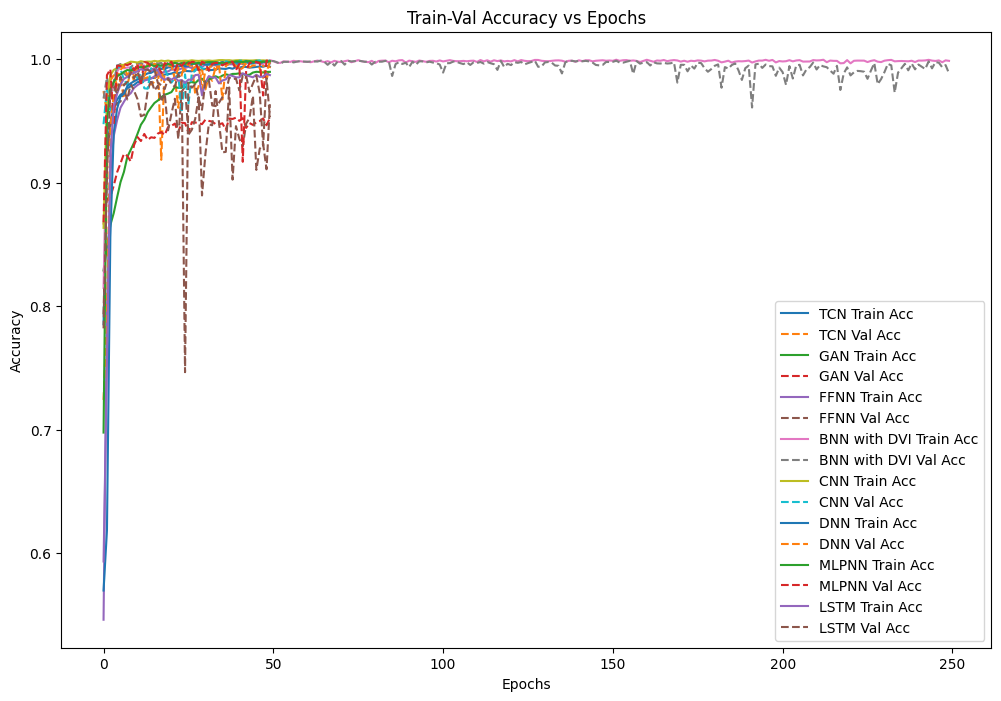

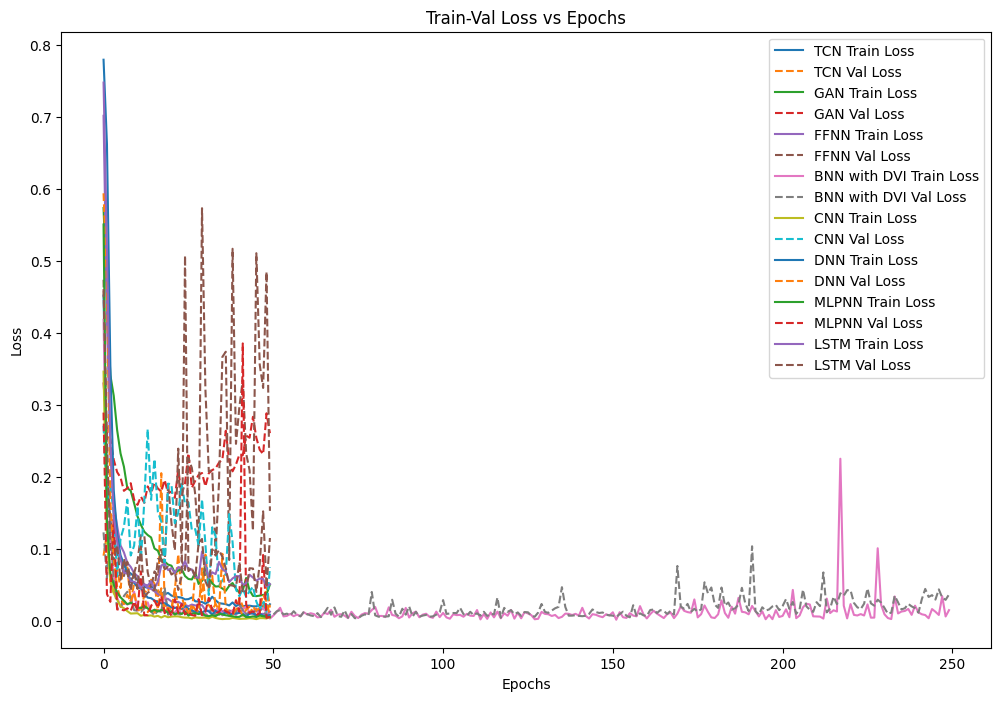

All plots generated.


In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout, BatchNormalization, LSTM, Conv1D, Conv2D,
                                     MaxPooling2D, Flatten, LeakyReLU, Input, Activation, SpatialDropout1D)

# Config
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

# Load test data
data = np.load(DATA_PATH, allow_pickle=True)
X_test = data['X_test']
y_test = data['y_test']

# Squeeze to 3D (samples, channels, timepoints)
X_test = np.squeeze(X_test, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for models expecting that format
X_test_3d = np.swapaxes(X_test, 1, 2)  # (samples, timepoints=125, channels=128)

# For CNN: Add channel dimension (samples, timepoints, channels, 1)
X_test_4d = np.expand_dims(X_test_3d, axis=-1)

# For flattened models: Flatten to 2D
X_test_flat = X_test_3d.reshape(X_test.shape[0], -1)

# Standardize X_test (flatten temporarily for scaling)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_test_flat_scaled = scaler.fit_transform(X_test_flat)  # Fit on test for standalone; use train scaler in practice

# Reshape back for 3D/4D if needed
X_test_3d_scaled = X_test_flat_scaled.reshape(X_test_3d.shape)
X_test_4d_scaled = np.expand_dims(X_test_3d_scaled, axis=-1)

time_steps = X_test_3d.shape[1]  # 125
channels = X_test_3d.shape[2]  # 128

# Define dynamic lists for weights and histories (user-specified paths)
model_names = ['TCN', 'GAN', 'FFNN', 'BNN with DVI', 'CNN', 'DNN', 'MLPNN', 'LSTM']
weight_list = [
    os.path.join(OUTPUT_DIR, '/kaggle/working/best_tcn_model_dotprobe.weights.h5'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/discriminator_dotprobe_main.weights.h5'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/best_ffnn_model_dotprobe.weights.h5'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/best_bnn_model_dotprobe.weights.h5'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/cnn_model_dotprobe_final.weights.h5'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/dnn_model_dotprobe_enhanced_final_main.weights.h5'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/mlpnn_model_dotprobe_final.weights.h5'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/lstm_model_dotprobe_final_main.weights.h5')
]
history_list = [
    os.path.join(OUTPUT_DIR, '/kaggle/working/tcn_training_history_dotprobe.npz'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/gan_training_history_dotprobe.npz'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/ffnn_training_history_dotprobe.npz'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/bnn_dvi_training_history_dotprobe.npz'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/cnn_training_history_dotprobe.npz'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/dnn_training_history_dotprobe_enhanced_main.npz'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/mlpnn_training_history_dotprobe.npz'),
    os.path.join(OUTPUT_DIR, '/kaggle/working/lstm_training_history_dotprobe.npz')
]

# Build model_configs dynamically from lists
model_configs = []
for name, weights, history in zip(model_names, weight_list, history_list):
    if name == 'TCN':
        build_func = lambda: (
            inputs := Input(shape=(time_steps, channels)),
            x := Conv1D(128, 3, padding='causal', dilation_rate=1)(inputs),
            x := BatchNormalization()(x),
            x := Activation('relu')(x),
            x := SpatialDropout1D(0.2)(x),
            x := Conv1D(128, 3, padding='causal', dilation_rate=2)(x),
            x := BatchNormalization()(x),
            x := Activation('relu')(x),
            x := SpatialDropout1D(0.2)(x),
            x := Conv1D(128, 3, padding='causal', dilation_rate=4)(x),
            x := BatchNormalization()(x),
            x := Activation('relu')(x),
            x := SpatialDropout1D(0.2)(x),
            x := Conv1D(128, 3, padding='causal', dilation_rate=8)(x),
            x := BatchNormalization()(x),
            x := Activation('relu')(x),
            x := SpatialDropout1D(0.2)(x),
            x := Flatten()(x),
            x := Dense(256, activation='relu')(x),
            x := Dropout(0.3)(x),
            outputs := Dense(1, activation='sigmoid')(x),
            Model(inputs=inputs, outputs=outputs)
        )[-1]
        is_3d = True
    elif name == 'GAN':
        build_func = lambda: Sequential([
            Dense(512, input_shape=(time_steps * channels,)), LeakyReLU(alpha=0.2), Dropout(0.4), Dense(256), LeakyReLU(alpha=0.2), Dropout(0.4), Dense(1, activation='sigmoid')])
        is_3d = False
    elif name == 'FFNN':
        build_func = lambda: Sequential([
            Conv1D(64, kernel_size=3, padding='same', input_shape=(time_steps, channels)),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            
            Conv1D(32, kernel_size=3, padding='same'),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            
            Flatten(),
            Dense(128),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            
            Dense(64),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            
            Dense(32),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            
            Dense(1, activation='sigmoid')
        ])
        is_3d = True
    elif name == 'BNN with DVI':
        build_func = lambda: Sequential([
            Conv1D(64, kernel_size=3, padding='same', activation='relu', input_shape=(time_steps, channels)),
            Dropout(0.5),
            Conv1D(32, kernel_size=3, padding='same', activation='relu'),
            Dropout(0.5),
            Flatten(),
            Dense(128, activation='relu'),
            Dropout(0.5),
            Dense(128, activation='relu'),
            Dropout(0.5),
            Dense(1, activation='sigmoid')
        ])
        is_3d = True
    elif name == 'CNN':
        build_func = lambda: Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(125, 128, 1)),  # Conv2D on 4D (time, channels, 1)
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
        is_3d = True
    elif name == 'DNN':
        build_func = lambda: Sequential([
            Conv1D(128, kernel_size=3, padding='same', input_shape=(time_steps, channels)),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            
            Conv1D(64, kernel_size=3, padding='same'),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            
            Conv1D(32, kernel_size=3, padding='same'),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            
            Flatten(),
            Dense(512),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            Dense(256),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            Dense(128),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            Dense(64),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            Dense(32),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            Dense(1, activation='sigmoid')
        ])
        is_3d = True
    elif name == 'MLPNN':
        build_func = lambda: Sequential([
            Conv1D(256, kernel_size=3, padding='same', input_shape=(time_steps, channels)),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            
            Conv1D(128, kernel_size=3, padding='same'),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            
            Conv1D(64, kernel_size=3, padding='same'),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            
            Conv1D(32, kernel_size=3, padding='same'),
            BatchNormalization(),
            LeakyReLU(alpha=0.1),
            Dropout(0.3),
            
            Flatten(),
            Dense(1, activation='sigmoid')
        ])
        is_3d = True
    elif name == 'LSTM':
        build_func = lambda: Sequential([
            LSTM(128, activation='tanh', return_sequences=True, input_shape=(time_steps, channels)),
            BatchNormalization(),
            Dropout(0.3),
            
            LSTM(64, activation='tanh', return_sequences=True),
            BatchNormalization(),
            Dropout(0.3),
            
            LSTM(32, activation='tanh'),
            BatchNormalization(),
            Dropout(0.3),
            
            Dense(64, activation='relu'),
            BatchNormalization(),
            Dropout(0.3),
            
            Dense(1, activation='sigmoid')
        ])
        is_3d = True
    
    model_configs.append({'name': name, 'weights': weights, 'history': history, 'is_3d': is_3d, 'build_func': build_func})

metrics = {}
histories = {}
for cfg in model_configs:
    name = cfg['name']
    weights_path = cfg['weights']
    history_path = cfg['history']
    
    if not os.path.exists(weights_path):
        print(f"Skipping {name}: Weights not found")
        continue
    
    model = cfg['build_func']()
    model.load_weights(weights_path)
    
    if name == 'CNN':
        test_data = X_test_4d_scaled
    elif name == 'GAN':
        test_data = X_test_flat_scaled  # Flat for GAN
    else:
        test_data = X_test_3d_scaled
    
    y_pred_prob = model.predict(test_data, verbose=0).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    metrics[name] = {
        'acc': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred),
        'fpr': roc_curve(y_test, y_pred_prob)[0],
        'tpr': roc_curve(y_test, y_pred_prob)[1],
        'auc': roc_auc_score(y_test, y_pred_prob)
    }
    
    if os.path.exists(history_path):
        h = np.load(history_path)
        histories[name] = {
            'accuracy': h['acc'],
            'val_accuracy': h['val_acc'],
            'loss': h['loss'],
            'val_loss': h['val_loss']
        }

# Plots if metrics available
if metrics:
    names = list(metrics.keys())
    
    # 1. Classification Report Plot (Table)
    fig, ax = plt.subplots(figsize=(12, len(names)*0.5 + 2))
    ax.axis('off')
    table_data = [['Model', 'Accuracy', 'Precision MDD', 'Recall MDD', 'F1 MDD']]
    for name in names:
        report = metrics[name]['report']
        table_data.append([name, f"{metrics[name]['acc']:.4f}", f"{report.get('1', {}).get('precision', 0):.4f}", f"{report.get('1', {}).get('recall', 0):.4f}", f"{report.get('1', {}).get('f1-score', 0):.4f}"])
    ax.table(cellText=table_data, colWidths=[0.2]*5, loc='center')
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_classification_report_main_best_final_last.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 2. Confusion Matrix Plot (Grid)
    fig, axs = plt.subplots(2, 4, figsize=(20, 10))
    axs = axs.ravel()
    for i, name in enumerate(names):
        sns.heatmap(metrics[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=axs[i])
        axs[i].set_title(name)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_confusion_matrix_main_best_final_last.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 3. ROC-AUC Plot
    plt.figure(figsize=(10, 8))
    for name in names:
        plt.plot(metrics[name]['fpr'], metrics[name]['tpr'], label=f'{name} (AUC = {metrics[name]["auc"]:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC-AUC Curves')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_roc_auc_main_best_final_last.png'), bbox_inches='tight')
    plt.show()
    plt.close()

# Plots if histories available
if histories:
    names_hist = list(histories.keys())
    
    # 4. Train-Val Accuracy vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['accuracy'], label=f'{name} Train Acc')
        plt.plot(histories[name]['val_accuracy'], '--', label=f'{name} Val Acc')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Train-Val Accuracy vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_train_val_accuracy_main_best_final_last.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 5. Train-Val Loss vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['loss'], label=f'{name} Train Loss')
        plt.plot(histories[name]['val_loss'], '--', label=f'{name} Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train-Val Loss vs Epochs')
    plt.legend()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dotprobe_all_train_val_loss_main_best_final_last.png'), bbox_inches='tight')
    plt.show()
    plt.close()

print("All plots generated.")